## Evaluation Demo

In this workbook, you can reproduce the figures which we include in our paper. In particular, we demonstrate the following tests:

1. Input sequence length evaluation              ✅
2. Triplet vs. quadruplet training loss function ✅ -- but the results of this comparison aren't great (both are amazing) -- need to find worse scenarios
3. Fingerprint's temporal consistency            ✅ -- but we need to refactor everything to make it look more pretty
4. Multi-RX fingerprinting                       ⏳ -- practically the same thing as (2), but: multi-RX weight-based evaluation
5. Dataset confusion matrices                    ⏳ -- same as (4), but for both closed set and open set, and multi-RX weight-based

Requirements:

* Software: Matlab (tested with R2024a)
* Datasets: `DatasetAPI.DATASET_V2` and `DatasetAPI.DATASET_V4`

In [2]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
import utils
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI

2024-10-30 00:54:32.463037: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-30 00:54:32.463087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-30 00:54:32.464444: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-30 00:54:32.470935: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-30 00:54:33.098910: W tensorflow/compiler/tf2

### Let's pick a dataset

For this project, we captured two separate datasets in the Orbit testbed facility. Both serve the same purpose, but have a few differentiations:

* `DatasetAPI.DATASET_V2`: focuses on long-term signal capture (>24hrs), but compromises on the number of emitting devices (9-10 throughout epochs). Signal is captured from 4 receivers.
* `DatasetAPI.DATASET_V4`: focuses on shorter-term signal capture (~4hrs), but provides a larger number of available emitters (20 throughout epochs). Signal is captured from 3 receivers.

Select which one you'd like to use for this experiment, and all the configurations will be adjusted accordingly ()

In [3]:
# utils.request_value_dropdown(
#     prompt='Dataset:',
#     options=['Undefined', DatasetAPI.DATASET_V2, DatasetAPI.DATASET_V4],
#     callback=lambda value: globals().update(DATASET_NAME=value) and print(f"DATASET_NAME is now set to: {value}"))

# DATASET_NAME = DatasetAPI.DATASET_V2
DATASET_NAME = DatasetAPI.DATASET_V4

### Let's configure the system

In the cell below, we configure the settings for the system. Here's high-level overview of what these configs mean:

* `ROOT_DIRECTORY`: this is the root directory, where we expect to find all the datasets
* `MATLAB_SRC_DIRECTORY`: a directory in this project, where we can access the Matlab code for running data augmentation scripts
* `MATLAB_SESSION_ID`: a live Matlab session name, which we'll connect to for running augmentation scripts
* `DATA_CONFIG`: a dict with configurations for how to work with the dataset
* `AUG_CONFIG`: a dict with configurations for how to augment the dataset
* `MODEL_CONFIG`: a dict with configurations for how we'll train the fingerprint extractor model
* `RX_NODES`: a list of RX node names, which is different for different datasets

In [4]:
ROOT_DIRECTORY =         '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY =   '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting'
MATLAB_SESSION_ID =      'fp_worklow'
AUG_ON =                 False

DATA_CONFIG = {
    'dataset_name':      DATASET_NAME,
    'frame_count_train': 200, # 200 for v2, 500 for v3
    'frame_count_epoch': 2,
    'samples_count':     400
}

AUG_CONFIG = {
    'multiplier':        5,
    't_rms_bounds':      matlab.double([1, 2]),
    'd_f_bounds':        matlab.double([0, 10]),
    'k_factor_bounds':   matlab.double([0, 10]),
    'awgn':              matlab.double([10, 50]),
}

MODEL_CONFIG = {
    'batch_size':        32,
    # 'loss_type':       'triplet_loss', 'loss_num_neg': 1,
    'loss_type':         'quadruplet_loss', 'loss_num_neg': 2,
    'npair_type':        'samedev',
    'alpha':             1.0, # used only for triple & quadruple loss
    'patience':          10,
    'fp_len':            512,
    'row':               50,
    'enable_ind':        False
}

# The only differences between the two datasets are the numbers of receivers from which
# we were able to capture the signal
if DATASET_NAME == DatasetAPI.DATASET_V4: RX_NODES = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_4]
else:                                     RX_NODES = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_3, DatasetAPI.RX_4]

### Next, we'll initialize the main APIs:

* `ExtractorAPI`: functions that are useful for working with the fingerprint extractor models (training, loading, etc)
* `DatasetAPI`: functions that are useful for working with the dataset (reading, filtration, transformation, etc)
* `FingerprintingAPI`: functions that are useful for running the fingerprinting tasks (vector similarity search, etc)
* `EvaluationAPI`: service functions for running experiments displayed in our paper, primarily invoked from this notebook

In [5]:
extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
fp_api = FingerprintingAPI(
    rx_ids = RX_NODES, 
    data_config=DATA_CONFIG, 
    aug_config=AUG_CONFIG,
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
eval_api = EvaluationAPI(
    rx_ids = RX_NODES, 
    data_config=DATA_CONFIG, 
    aug_config=AUG_CONFIG, 
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)

### Let's prepare the models

Here, you have two options:

* Option A: load pre-trained models (they would be stored in the `my_models` dir in the pre-processed dataset folder)
* Option B: train separate models for each RX from scratch (obviously, takes much longer to complete)

In [5]:
# fp_api.load_models()
fp_api.train_models(apply_noise=False)

2024-10-21 02:06:46.787864: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 77750 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-10-21 02:06:46.789293: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78640 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-10-21 02:06:46.790586: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 78640 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


Applying quadruplet_loss
Epoch 1/1000


2024-10-21 02:06:49.209062: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905
2024-10-21 02:06:51.395339: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f8acc0a7c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-10-21 02:06:51.395385: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-10-21 02:06:51.395402: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-10-21 02:06:51.395412: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-10-21 02:06:51.399992: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1729490811.499311  478136 device_compi

140/140 [==============================] - 8s 24ms/step - loss: 0.3026 - val_loss: 0.1161 - lr: 0.0010
Epoch 2/1000
140/140 [==============================] - 2s 18ms/step - loss: 0.1098 - val_loss: 0.0701 - lr: 0.0010
Epoch 3/1000
140/140 [==============================] - 2s 17ms/step - loss: 0.0734 - val_loss: 0.0818 - lr: 0.0010
Epoch 4/1000
140/140 [==============================] - 2s 16ms/step - loss: 0.0580 - val_loss: 0.0554 - lr: 0.0010
Epoch 5/1000
140/140 [==============================] - 2s 17ms/step - loss: 0.0419 - val_loss: 0.0280 - lr: 0.0010
Epoch 6/1000
140/140 [==============================] - 3s 18ms/step - loss: 0.0347 - val_loss: 0.0237 - lr: 0.0010
Epoch 7/1000
140/140 [==============================] - 2s 18ms/step - loss: 0.0311 - val_loss: 0.0303 - lr: 0.0010
Epoch 8/1000
140/140 [==============================] - 2s 18ms/step - loss: 0.0222 - val_loss: 0.0223 - lr: 0.0010
Epoch 9/1000
140/140 [==============================] - 3s 18ms/step - loss: 0.0166 -

({'node1-1': <keras.src.engine.functional.Functional at 0x7f8e0f4b3700>,
  'node1-20': <keras.src.engine.functional.Functional at 0x7f8e088a7340>,
  'node19-19': <keras.src.engine.functional.Functional at 0x7f8e073df310>},
 {'node1-1': <keras.src.callbacks.History at 0x7f8e09f2e170>,
  'node1-20': <keras.src.callbacks.History at 0x7f8e08940a90>,
  'node19-19': <keras.src.callbacks.History at 0x7f8e07405960>})

### Plot the model layers and testbed topology map

This step is optional, but if you'd like to explore the composition of the fingerprint extractor model, run the next cell. You will find two types of printout: a figure (using `visualkeras`) and a standard model summary printout in the terminal.

{'1-1': 0, '1-2': 1, '1-3': 2, '1-4': 3, '1-5': 4, '1-6': 5, '1-7': 6, '1-8': 7, '1-9': 8, '1-10': 9, '1-11': 10, '1-12': 11, '1-13': 12, '1-14': 13, '1-15': 14, '1-16': 15, '1-17': 16, '1-18': 17, '1-19': 18, '1-20': 19, '2-1': 20, '2-2': 21, '2-3': 22, '2-4': 23, '2-5': 24, '2-6': 25, '2-7': 26, '2-8': 27, '2-9': 28, '2-10': 29, '2-11': 30, '2-12': 31, '2-13': 32, '2-14': 33, '2-15': 34, '2-16': 35, '2-17': 36, '2-18': 37, '2-19': 38, '2-20': 39, '3-1': 40, '3-2': 41, '3-3': 42, '3-4': 43, '3-5': 44, '3-6': 45, '3-7': 46, '3-8': 47, '3-9': 48, '3-10': 49, '3-11': 50, '3-12': 51, '3-13': 52, '3-14': 53, '3-15': 54, '3-16': 55, '3-17': 56, '3-18': 57, '3-19': 58, '3-20': 59, '4-1': 60, '4-2': 61, '4-3': 62, '4-4': 63, '4-5': 64, '4-6': 65, '4-7': 66, '4-8': 67, '4-9': 68, '4-10': 69, '4-11': 70, '4-12': 71, '4-13': 72, '4-14': 73, '4-15': 74, '4-16': 75, '4-17': 76, '4-18': 77, '4-19': 78, '4-20': 79, '5-1': 80, '5-2': 81, '5-3': 82, '5-4': 83, '5-5': 84, '5-6': 85, '5-7': 86, '5-8': 8

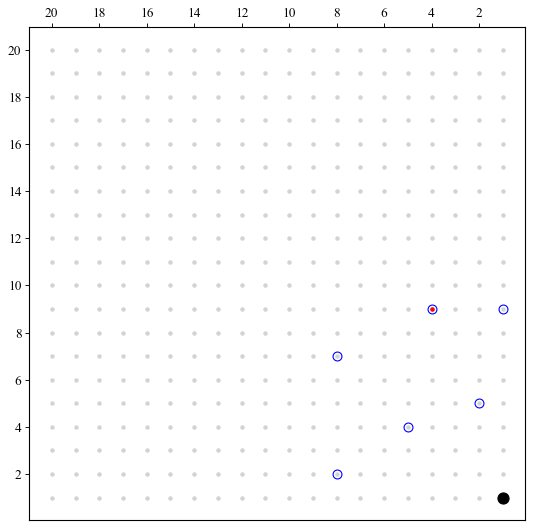

In [19]:
utils.apply_ieee_style()

ids, node_coordinates = utils.generate_grid_node_ids()

print(ids)

eval_api.render_orbit_grid(
    # tx_node_ids_1 = DatasetAPI.DATASET_V4_TX_MAX_DEVICES, 
    # tx_node_ids_2 = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS, 
    # rx_node_ids = [1, 20, 381, 379], 
    # tx_node_ids_1=[9, 11, 15, 17, 25, 38, 52, 57, 60, 69, 80, 84, 129, 130, 133, 142, 147, 157, 190, 196, 203, 206, 239, 242, 280, 300, 315, 329, 330, 360, 378, 380, 391],
    # tx_node_ids_1=[9, 11, 15, 17, 25, 38],
    tx_node_ids_1=[9, 25, 69, 84, 142, 147],
    tx_node_ids_2=[],
    rx_node_ids = [1],
    tx_node_id_curr = 69)

    # 9, 25, 69, 84, 142, 147

In [67]:
fp_api.models[DatasetAPI.RX_1].summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 50, 14, 1)]          0         []                            
                                                                                                  
 conv2d_10 (Conv2D)          (None, 25, 7, 32)            1600      ['input_6[0][0]']             
                                                                                                  
 conv2d_11 (Conv2D)          (None, 25, 7, 32)            9248      ['conv2d_10[0][0]']           
                                                                                                  
 re_lu_8 (ReLU)              (None, 25, 7, 32)            0         ['conv2d_11[0][0]']           
                                                                                            

### Experiment 1. The impact of the preamble

To train the fingerprint extractor, we are using preambles of 802.11 frames. This raises a few questions:

* Why preambles? Why can't we use other sections of an OFDM frame
* Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?

To answer these questions, we perform the following experiments:

1. We train the model on 802.11 preambles, and test enrollment/identification on sections of frames with a shifting start index;
2. Next, we also try training the model on non-preamble section of a frame (index 400-800), and repeat the same testing plan.
3. Importantly, since we're performing simple A/B tests, we only evaluate performance for a closed-set problem (via KNN classification), for a single receiver, and for only two epochs.

These results can let us answer the questions above:

* **Why preambles? Why can't we use other sections of an OFDM frame** -- because this is the only section of a frame that doesn't contain "random" data. We can see this by reviewing the 2nd figure. Since the model was trained on non-preamble samples, the max accuracy the model ever achieves is 65%, which is not acceptable.

* **Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?** -- The model doesn't extract only hardware imperfections. The fingerprints incorporate data-specific features as well, which makes it essential to use the exact same preamble section for training & testing.

Load the training dataset
Processing offset 0
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.


2024-10-04 12:23:39.627393: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905


29/29 [==============================] - 0s 2ms/step
Accuracy: 99.33%
Processing offset 1
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 99.0%
Processing offset 2
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 99.11%
Processing offset 3
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 98.0%
Processing offset 4
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 95.11%
Processing offset 5
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [====================

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Accuracy: 12.89%


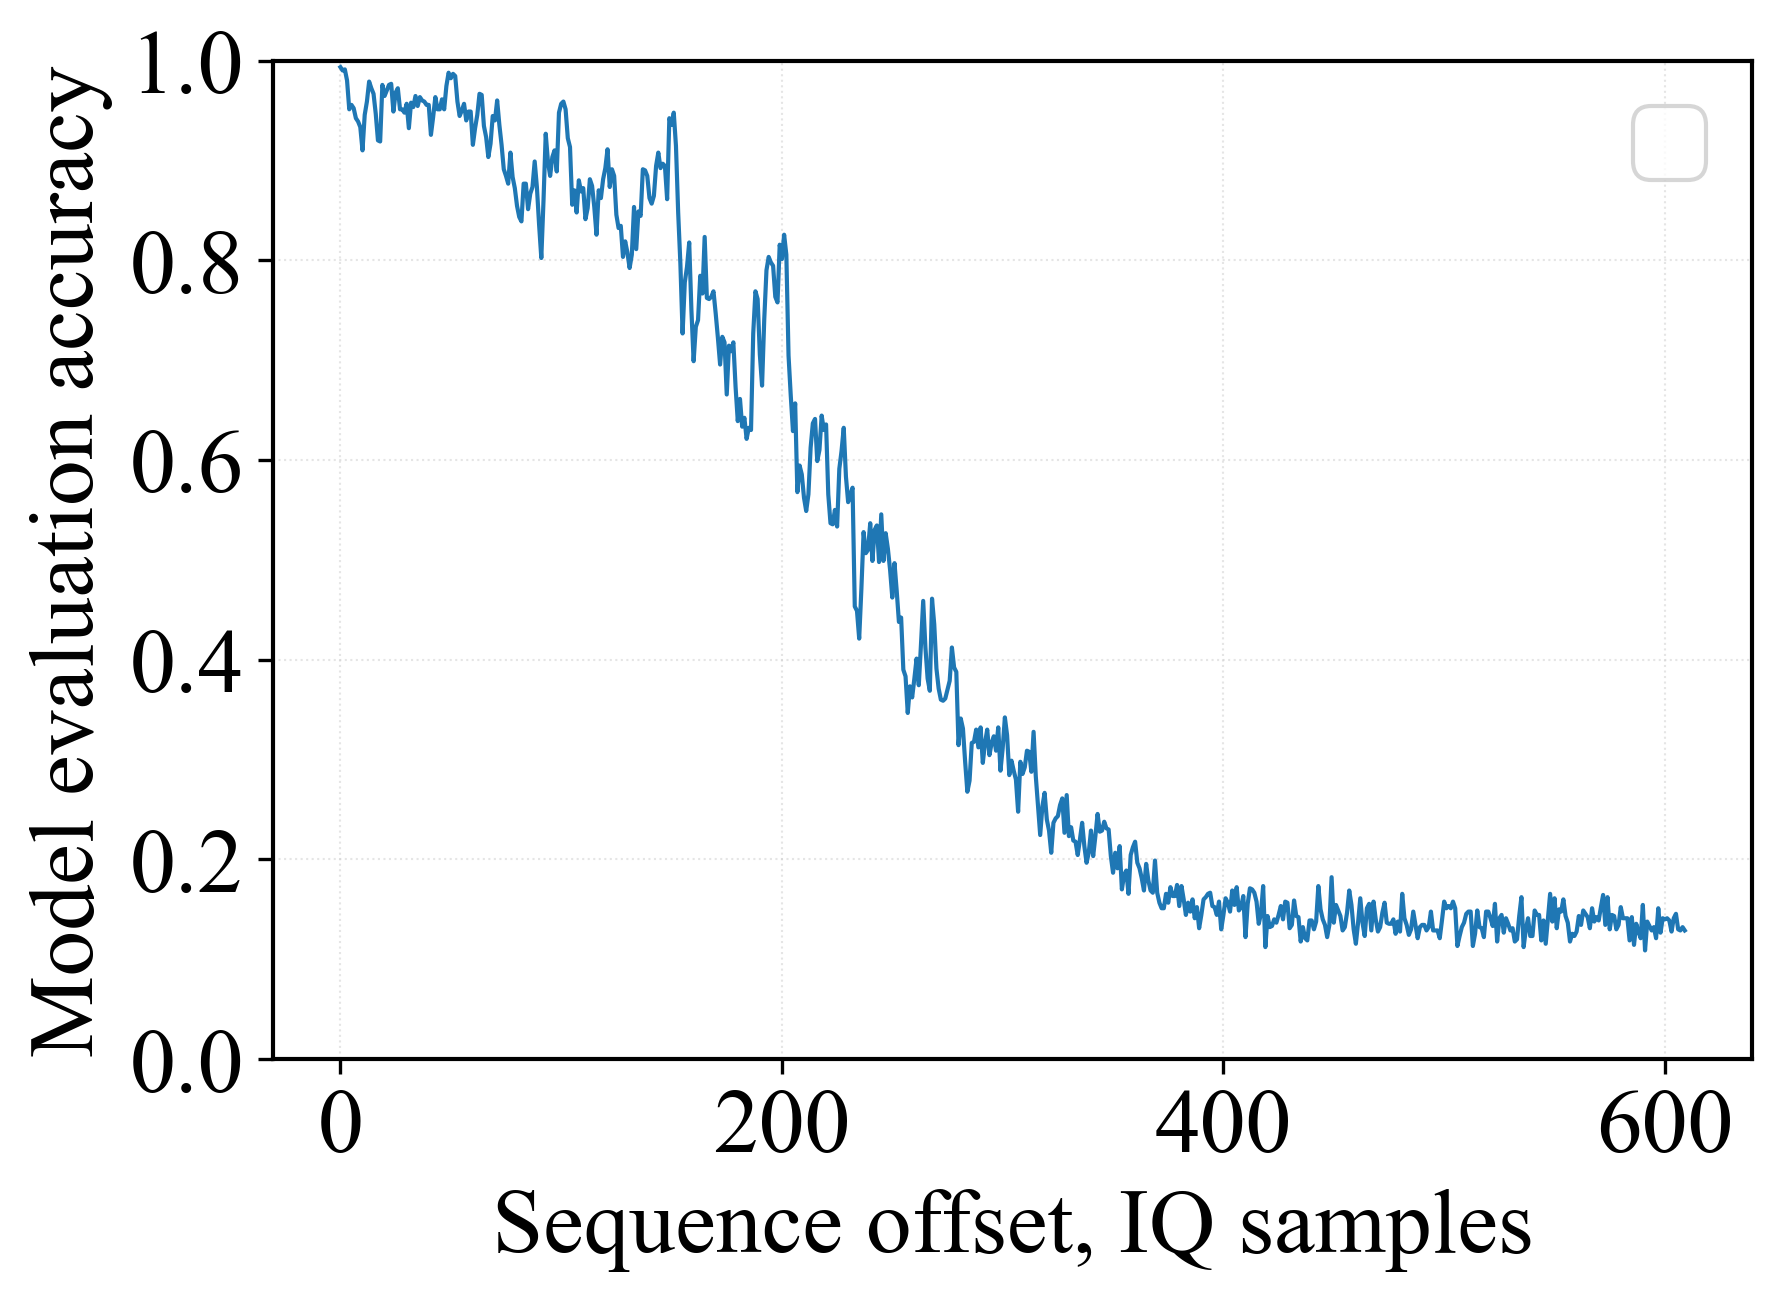

Load the training dataset
Applying quadruplet_loss
Epoch 1/1000


2024-10-04 12:31:50.905823: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f60168f1e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-10-04 12:31:50.905875: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-10-04 12:31:50.905883: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-10-04 12:31:50.905889: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-10-04 12:31:50.915692: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1728059511.013884  290152 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 [==============================] - 7s 21ms/step - loss: 1.5006 - val_loss: 1.4994 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 18ms/step - loss: 1.4946 - val_loss: 1.4629 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 18ms/step - loss: 1.4852 - val_loss: 1.4831 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 3s 19ms/step - loss: 1.4988 - val_loss: 1.4510 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 3s 19ms/step - loss: 1.4887 - val_loss: 1.4569 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 3s 18ms/step - loss: 1.4673 - val_loss: 1.5489 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 3s 19ms/step - loss: 1.4525 - val_loss: 1.4526 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 3s 18ms/step - loss: 1.4600 - val_loss: 1.4676 - lr: 0.0010
Epoch 9/1000
163/163 [==============================] - 3s 18ms/step - loss: 1.4616 -

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Accuracy: 11.44%


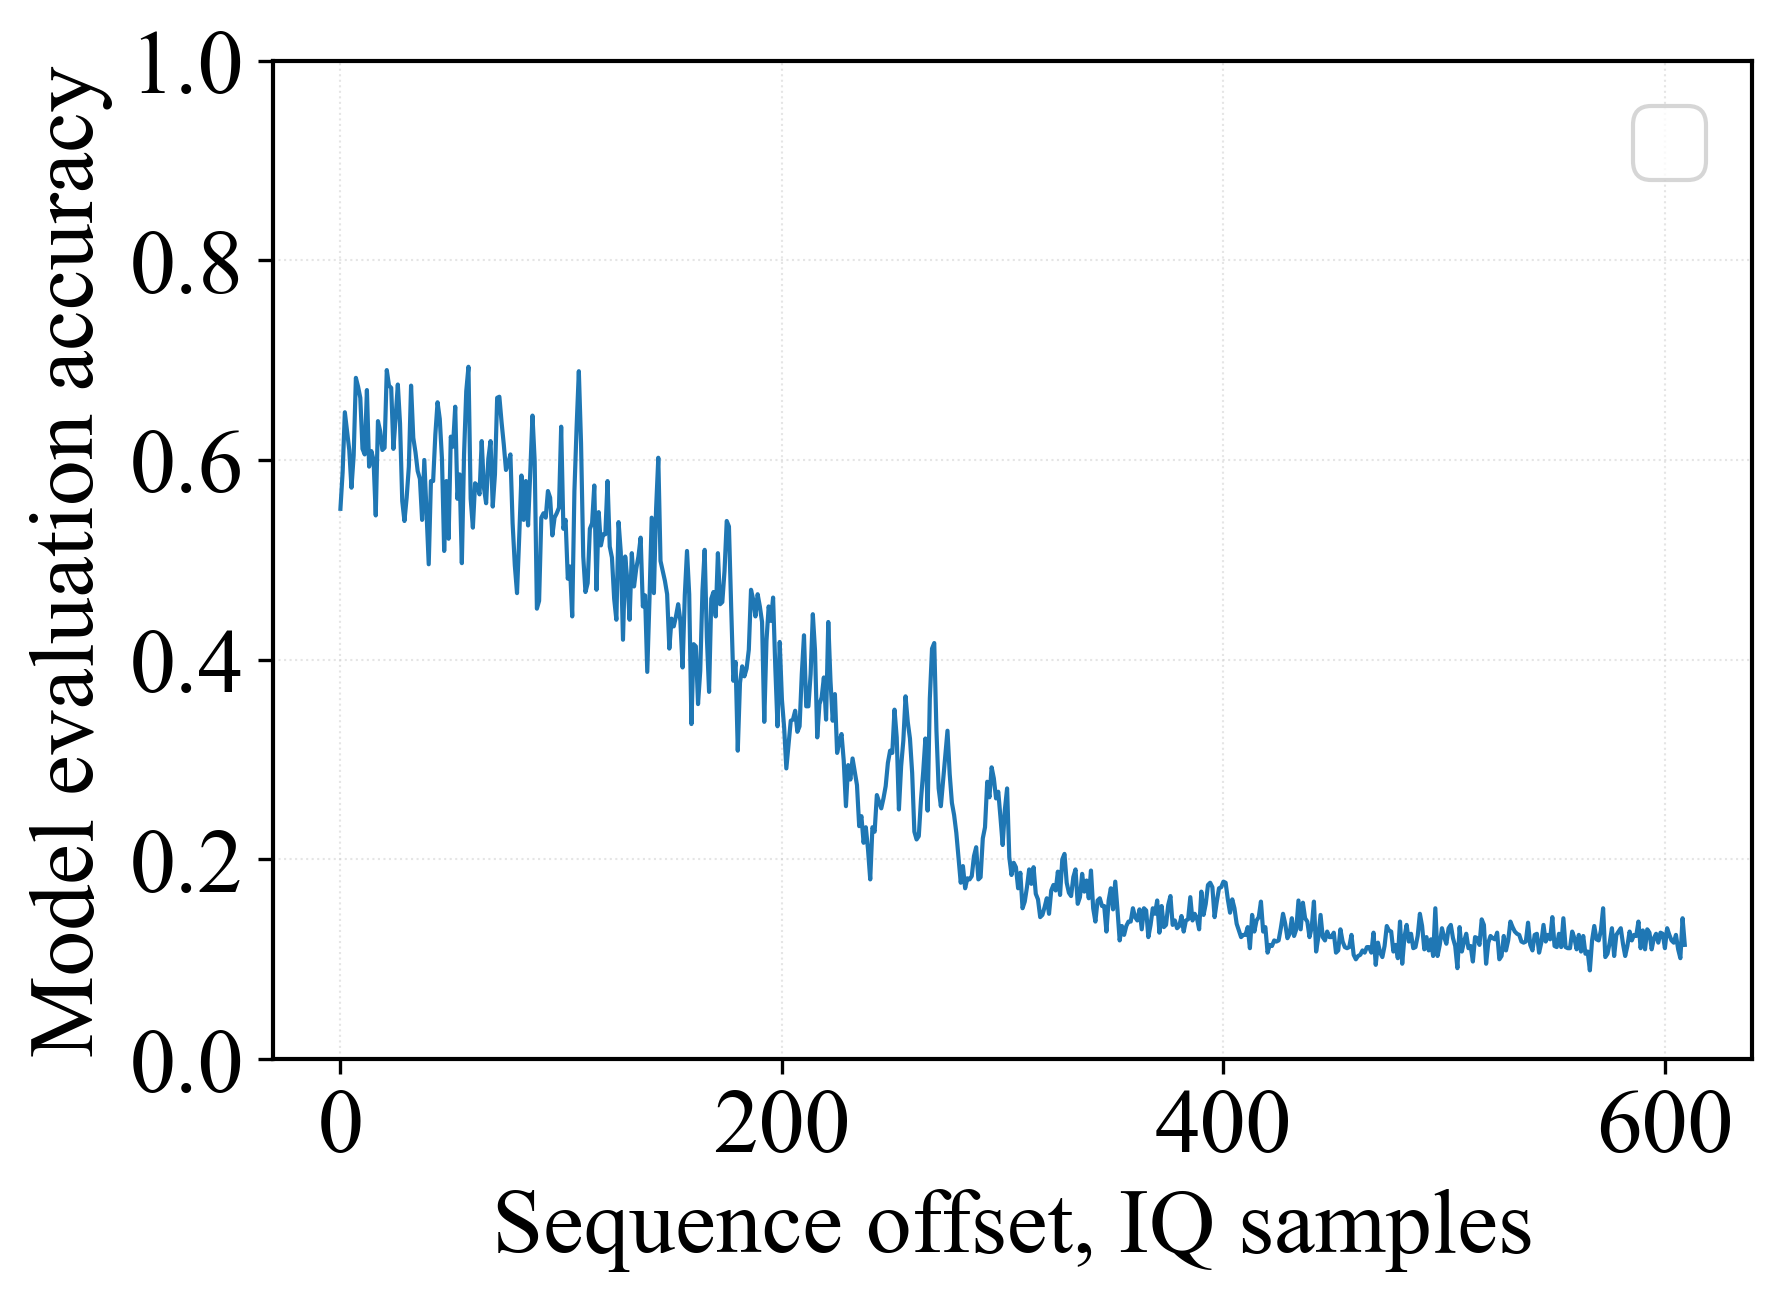

Done


In [23]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
else:
    print(f'No configs for {DATASET_NAME}')


eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, 
                                  frame_start_train=0, offset_range=np.arange(0, 610, 1), use_pretrained=True, 
                                  fig_name="Preamble offset evaluation: preamble-based training",
                                  fig_path=os.path.join(ROOT_DIRECTORY, 'fig1.eps'),
                                  enroll_device_idx = enroll_device_idx,
                                  identify_device_idx = identify_device_idx)
eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, 
                                  frame_start_train=400, offset_range=np.arange(0, 610, 1), use_pretrained=False, 
                                  fig_name="Preamble offset evaluation: random data-based training",
                                  fig_path=os.path.join(ROOT_DIRECTORY, 'fig2.eps'),
                                  enroll_device_idx = enroll_device_idx,
                                  identify_device_idx = identify_device_idx)

print('Done')

### 2. Experiment #2: Triplet vs. quadruplet training loss function

Every bit matters. Let's try adopting a quadruplet loss function and explore model performance on an identical dataset & settings.

Note: currently, the test is being performed under open-set conditions. You can override this by defining identical device ID sets in this function, and run closed-set test.

Load the training dataset
Evaluating for triplet_loss
Applying triplet_loss
Epoch 1/1000
140/140 [==============================] - 4s 16ms/step - loss: 0.1393 - val_loss: 0.0383 - lr: 0.0010
Epoch 2/1000
140/140 [==============================] - 2s 15ms/step - loss: 0.0272 - val_loss: 0.0160 - lr: 0.0010
Epoch 3/1000
140/140 [==============================] - 2s 15ms/step - loss: 0.0118 - val_loss: 0.0066 - lr: 0.0010
Epoch 4/1000
140/140 [==============================] - 2s 15ms/step - loss: 0.0081 - val_loss: 0.0055 - lr: 0.0010
Epoch 5/1000
 52/140 [==========>...................] - ETA: 1s - loss: 0.0039

140/140 [==============================] - 2s 14ms/step - loss: 0.0038 - val_loss: 0.0011 - lr: 0.0010
Epoch 6/1000
140/140 [==============================] - 2s 14ms/step - loss: 0.0028 - val_loss: 0.0033 - lr: 0.0010
Epoch 7/1000
140/140 [==============================] - 2s 14ms/step - loss: 0.0025 - val_loss: 0.0013 - lr: 0.0010
Epoch 8/1000
140/140 [==============================] - 2s 14ms/step - loss: 0.0012 - val_loss: 0.0012 - lr: 0.0010
Epoch 9/1000
140/140 [==============================] - 2s 14ms/step - loss: 0.0011 - val_loss: 1.9655e-04 - lr: 0.0010
Epoch 10/1000
140/140 [==============================] - 2s 13ms/step - loss: 0.0011 - val_loss: 0.0012 - lr: 0.0010
Epoch 11/1000
140/140 [==============================] - 2s 14ms/step - loss: 0.0011 - val_loss: 1.9681e-04 - lr: 0.0010
Epoch 12/1000
140/140 [==============================] - 2s 13ms/step - loss: 7.8864e-04 - val_loss: 6.3245e-04 - lr: 0.0010
Epoch 13/1000
140/140 [==============================] - 2s 15ms/s

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


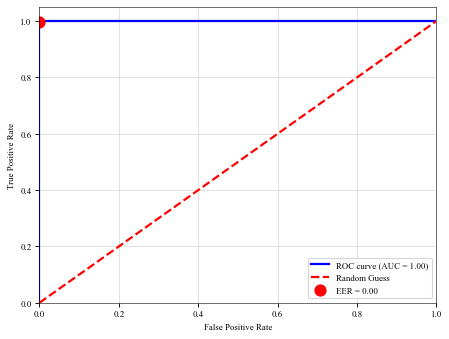

Evaluating for quadruplet_loss
Applying quadruplet_loss
Epoch 1/1000
140/140 [==============================] - 5s 18ms/step - loss: 0.4818 - val_loss: 0.2476 - lr: 0.0010
Epoch 2/1000
140/140 [==============================] - 2s 16ms/step - loss: 0.1812 - val_loss: 0.1485 - lr: 0.0010
Epoch 3/1000
140/140 [==============================] - 2s 16ms/step - loss: 0.1176 - val_loss: 0.0993 - lr: 0.0010
Epoch 4/1000
140/140 [==============================] - 2s 16ms/step - loss: 0.0874 - val_loss: 0.0639 - lr: 0.0010
Epoch 5/1000
140/140 [==============================] - 2s 17ms/step - loss: 0.0675 - val_loss: 0.0583 - lr: 0.0010
Epoch 6/1000
140/140 [==============================] - 2s 17ms/step - loss: 0.0417 - val_loss: 0.0370 - lr: 0.0010
Epoch 7/1000
140/140 [==============================] - 2s 16ms/step - loss: 0.0356 - val_loss: 0.0356 - lr: 0.0010
Epoch 8/1000
140/140 [==============================] - 2s 16ms/step - loss: 0.0280 - val_loss: 0.0259 - lr: 0.0010
Epoch 9/1000
140

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


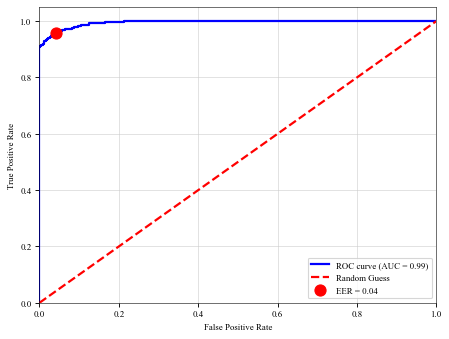

In [8]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
else:
    print(f'No configs for {DATASET_NAME}')

eval_api.evaluate_loss_function(rx_id = DatasetAPI.RX_1, fig_path = ROOT_DIRECTORY, enroll_device_idx=enroll_device_idx, identify_device_idx=identify_device_idx)

### Experiment 3. Fingerprint's temporal consistency

Generating eval finerprints for node1-1...
1/1 [==============================] - 0s 29ms/step
Generating eval finerprints for node1-20...
1/1 [==============================] - 0s 26ms/step
Generating eval finerprints for node20-1...
1/1 [==============================] - 0s 27ms/step
Generating eval finerprints for node19-19...
1/1 [==============================] - 0s 26ms/step


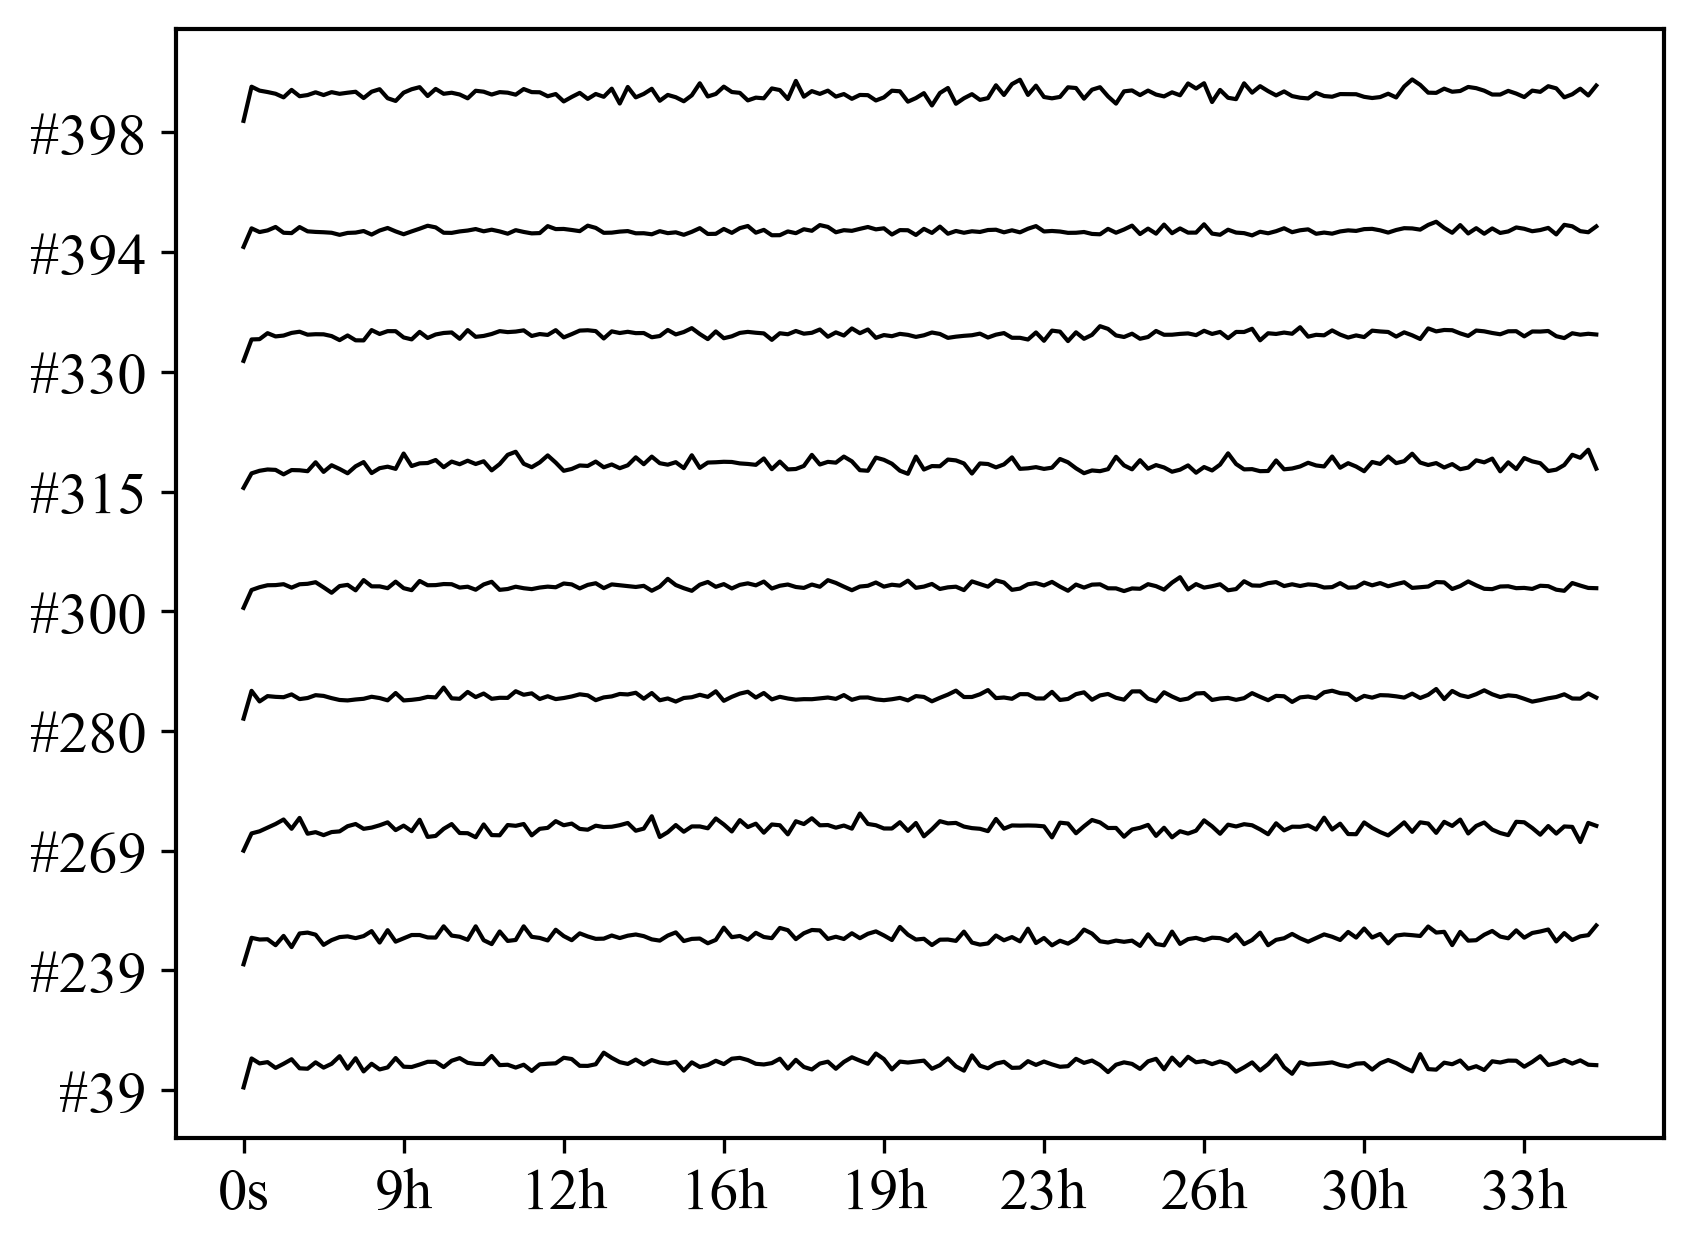

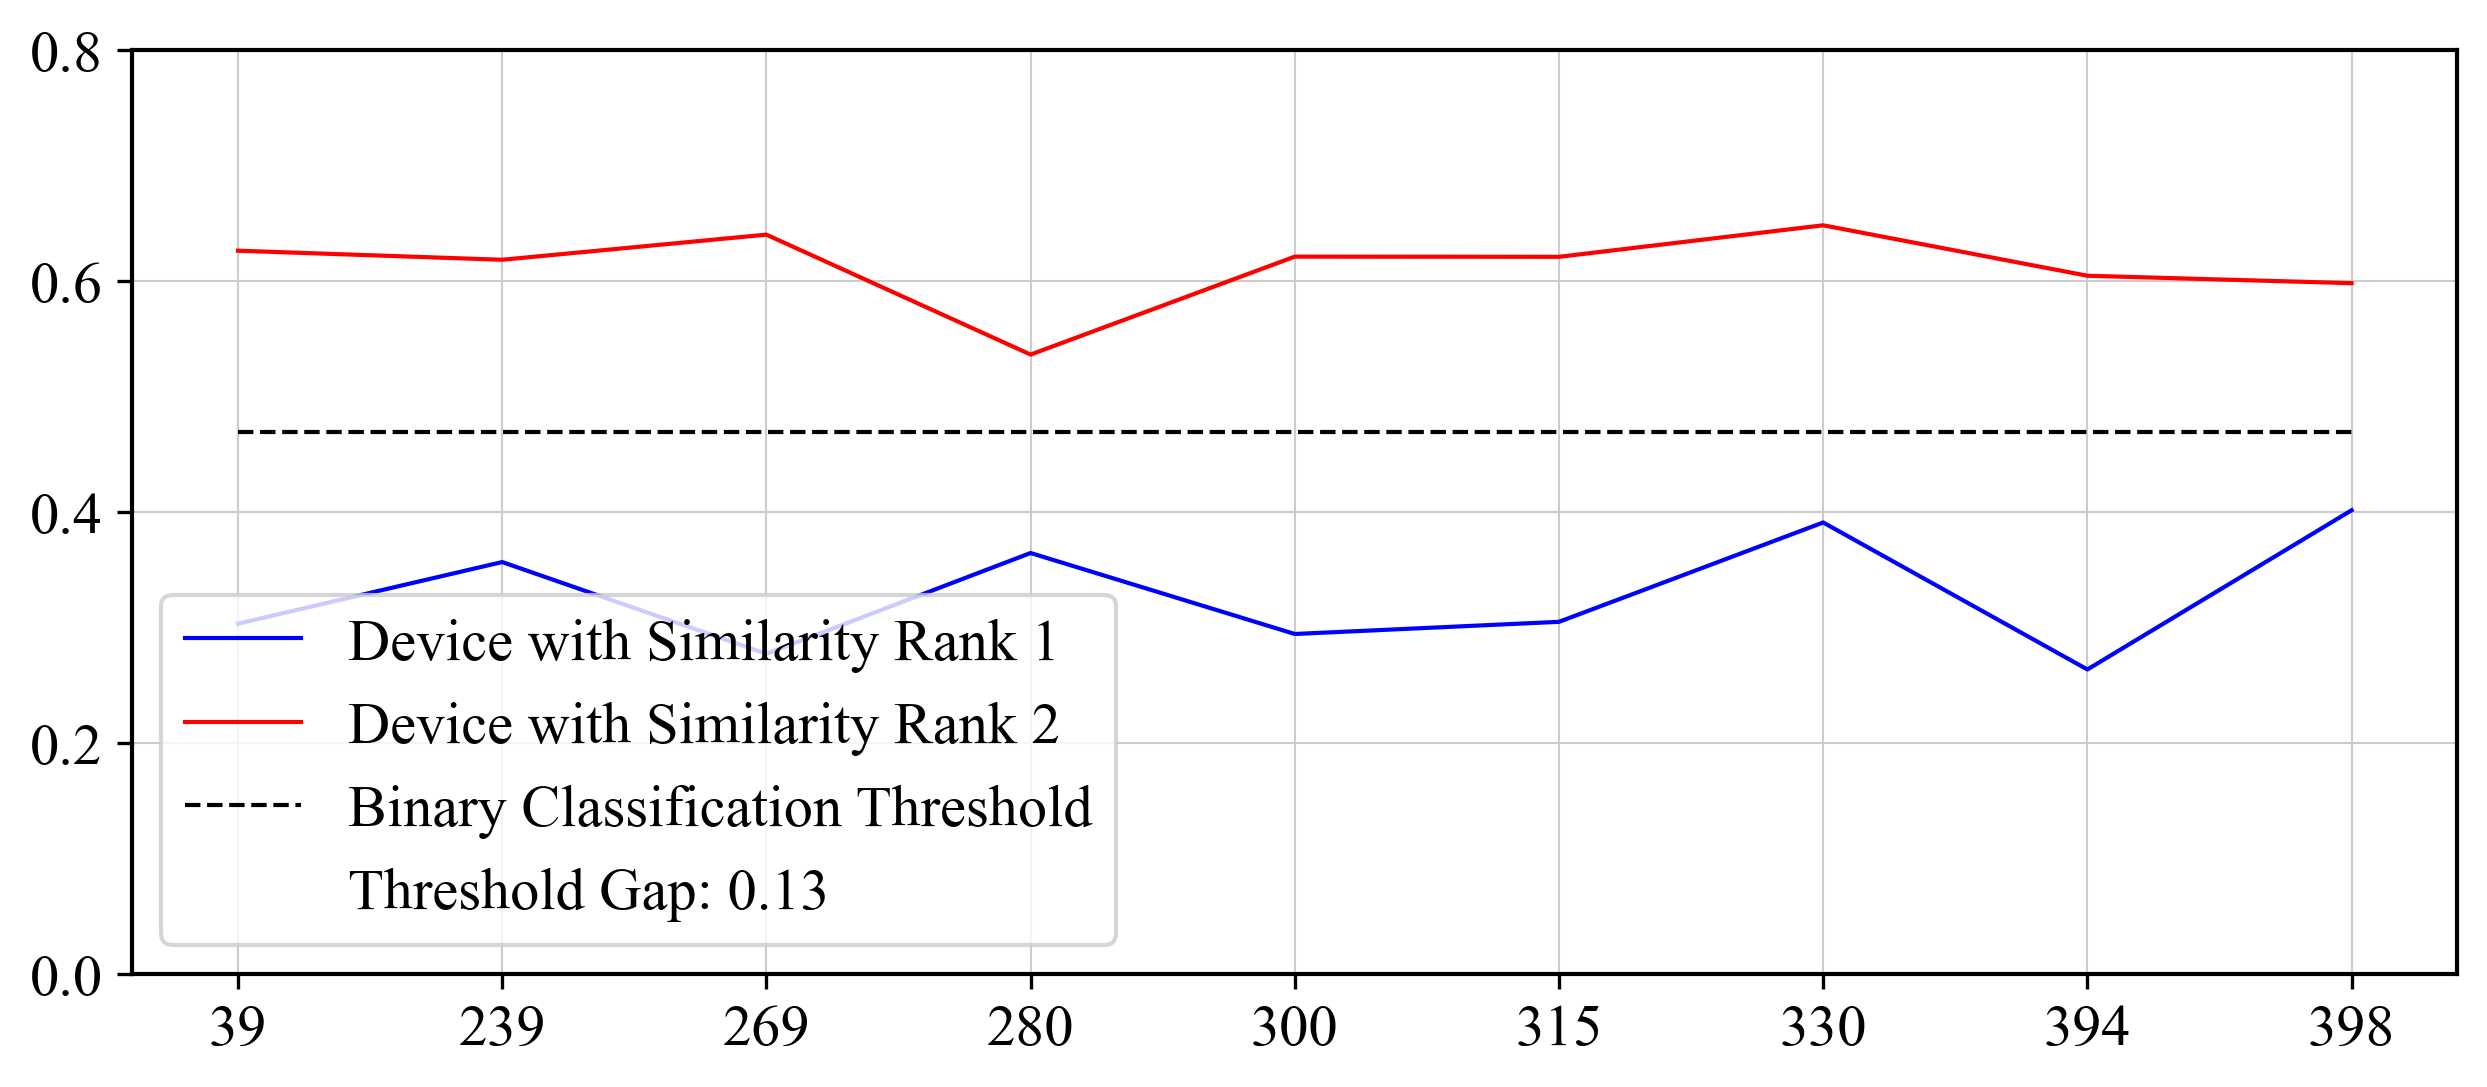

In [47]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    node_ids_epoch_override=DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
    epochs_override=DatasetAPI.DATASET_V2_EPOCHS_MAX_DEVICES
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    node_ids_epoch_override=DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
    epochs_override=DatasetAPI.DATASET_V4_EPOCHS_MAX_DEVICES
else:
    print(f'No configs for {DATASET_NAME}')

# models, _ = fp_api.train_models(apply_noise=False)
models = fp_api.load_models()

fp_distances = eval_api.evaluate_temporal_stability(
    models, RX_NODES, 
    node_ids_epoch=node_ids_epoch_override, 
    epochs_override=epochs_override, 
    fig_path=ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=True, 
    rank_dist_fig_file = False)

### Experiment 4. Multi-RX fingerprinting

The task here is slightly more interesting. While previously we evaluated the process of training the model, as well as whether the model can extract time-insensitive features -- now we can consider whether it's possible to improve the system performance by combining (aka fusing) fingerprints from multiple receivers that "hear" our signal simultaneously. 

This requires a slightly different process. Previous model tests could be performed while using a simple KNN-based evaluator. This step requires building out a custom evaluator, which is going to let us combine KNN distances with our custom weight factor -- RSSI (normalized between 0 and 1 on a -100 to 0 dB scale). 

Here's how this evaluation will work: 

1. We will build an evaluator which performs the evaluation process using a custom list of receivers. 
2. We will then run this evaluator for the following combinations:
    * RX 1
    * RX 2
    * RX 3
    * RX 4
    * RX 1, 2
    * RX 1, 2, 3
    * rX 1, 2, 3, 4
3. We will compare their performance on both closed-set and open-set scenarios, and produce the same accuracy metrics as before
4. Optionally, we will let the user render a rank 1-2 plot across all devices

In [6]:
from dataset_preparation import awgn

if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
else:
    print(f'No configs for {DATASET_NAME}')

print(enroll_device_idx)
print(identify_device_idx)

aug_on = False
apply_noise = False

epoch_idx_enroll = 0
epoch_idx_identify = 1

frame_count_enroll = frame_count_identify = 100

models = {}
data_epochs_1 = {}
labels_epochs_1 = {}
data_epochs_2 = {}
labels_epochs_2 = {}
rssis_epoch_2 = {}

for rx_id in RX_NODES:
    print(f"Load the training dataset for {rx_id}")
    dataset_train_path, dataset_epoch_paths, model_path, node_ids_train, _, samp_rate = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], rx_id, None)
    if aug_on: data, label, rssi = dataset_api.load_augmented_dataset(dataset_train_path, samp_rate, AUG_CONFIG, shuffle=True)
    else: data, label, rssi = dataset_api.load_raw_dataset(dataset_train_path, shuffle=True)
    data, label, rssi = dataset_api.filter_dataset(data, label, rssi, node_ids_train, np.arange(0, DATA_CONFIG['frame_count_train']))
    if apply_noise: data = awgn(data, np.arange(AUG_CONFIG['awgn'][0][0], AUG_CONFIG['awgn'][0][1]))
    data_train = data[:, 0:0+DATA_CONFIG['samples_count']]

    # feature_extractor, _ = extractor_api.train(data_train, label, node_ids_train, MODEL_CONFIG, save_path=None)
    models[rx_id] = extractor_api.load(os.path.join(model_path, f"extractor_{rx_id}.keras"))

    # Load data (two epochs: one to enroll devices, another to identify devices)
    data_enroll, labels_enroll, rssi_enroll = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_enroll], shuffle=True)
    data_identify, labels_identify, rssi_identify = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_identify], shuffle=True)

    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, rssi_enroll, dev_range=enroll_device_idx, pkt_range=np.arange(frame_count_enroll))
    data_identify, labels_identify, rssi_identify = dataset_api.filter_dataset(data_identify, labels_identify, rssi_identify, dev_range=identify_device_idx, pkt_range=np.arange(frame_count_identify))

    data_epochs_1[rx_id] = data_enroll[:, 0:DATA_CONFIG['samples_count']]
    data_epochs_2[rx_id] = data_identify[:, 0:DATA_CONFIG['samples_count']]

    labels_epochs_1[rx_id] = labels_enroll
    labels_epochs_2[rx_id] = labels_identify

    rssis_epoch_2[rx_id] = rssi_identify

[1, 259, 10, 269, 398]
[1, 259, 10, 269, 398, 247, 280, 186, 315, 189]
Load the training dataset for node1-1
Load the training dataset for node1-20
Load the training dataset for node19-19


Great! Epoch #2 contains more devices than #1, and #1 is a subset of #2. Running open-set for RX: ['node1-1', 'node1-20', 'node19-19']
32/32 [==============================] - 0s 2ms/step


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


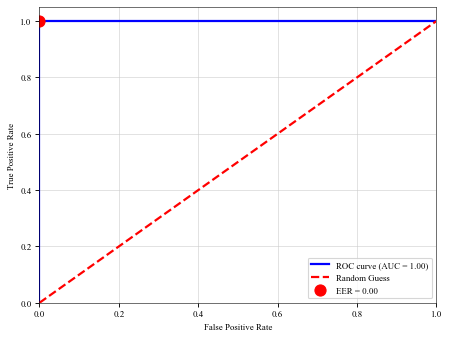

In [12]:
# eval_api.evaluate_open_set_knn_multirx(
#     models, RX_NODES[0:1], 
#     data_epochs_1, labels_epochs_1, 
#     data_epochs_2, labels_epochs_2, rssis_epoch_2, 
#     MODEL_CONFIG, fig_path=os.path.join(ROOT_DIRECTORY, 'multirx_open_set_rx1.eps'))

# eval_api.evaluate_open_set_knn_multirx(
#     models, RX_NODES[0:2], 
#     data_epochs_1, labels_epochs_1, 
#     data_epochs_2, labels_epochs_2, rssis_epoch_2, 
#     MODEL_CONFIG, fig_path=os.path.join(ROOT_DIRECTORY, 'multirx_open_set_rx12.eps'))

# eval_api.evaluate_open_set_knn_multirx(
#     models, RX_NODES[0:3], 
#     data_epochs_1, labels_epochs_1, 
#     data_epochs_2, labels_epochs_2, rssis_epoch_2, 
#     MODEL_CONFIG, fig_path=os.path.join(ROOT_DIRECTORY, 'multirx_open_set_rx123.eps'))

# Use all available nodes
eval_api.evaluate_open_set_knn_multirx(
    models, RX_NODES, 
    data_epochs_1, labels_epochs_1, 
    data_epochs_2, labels_epochs_2, rssis_epoch_2, 
    MODEL_CONFIG, fig_path=os.path.join(ROOT_DIRECTORY, 'multirx_open_set_rx1234.eps'))

Generating eval finerprints for node1-20...
..

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


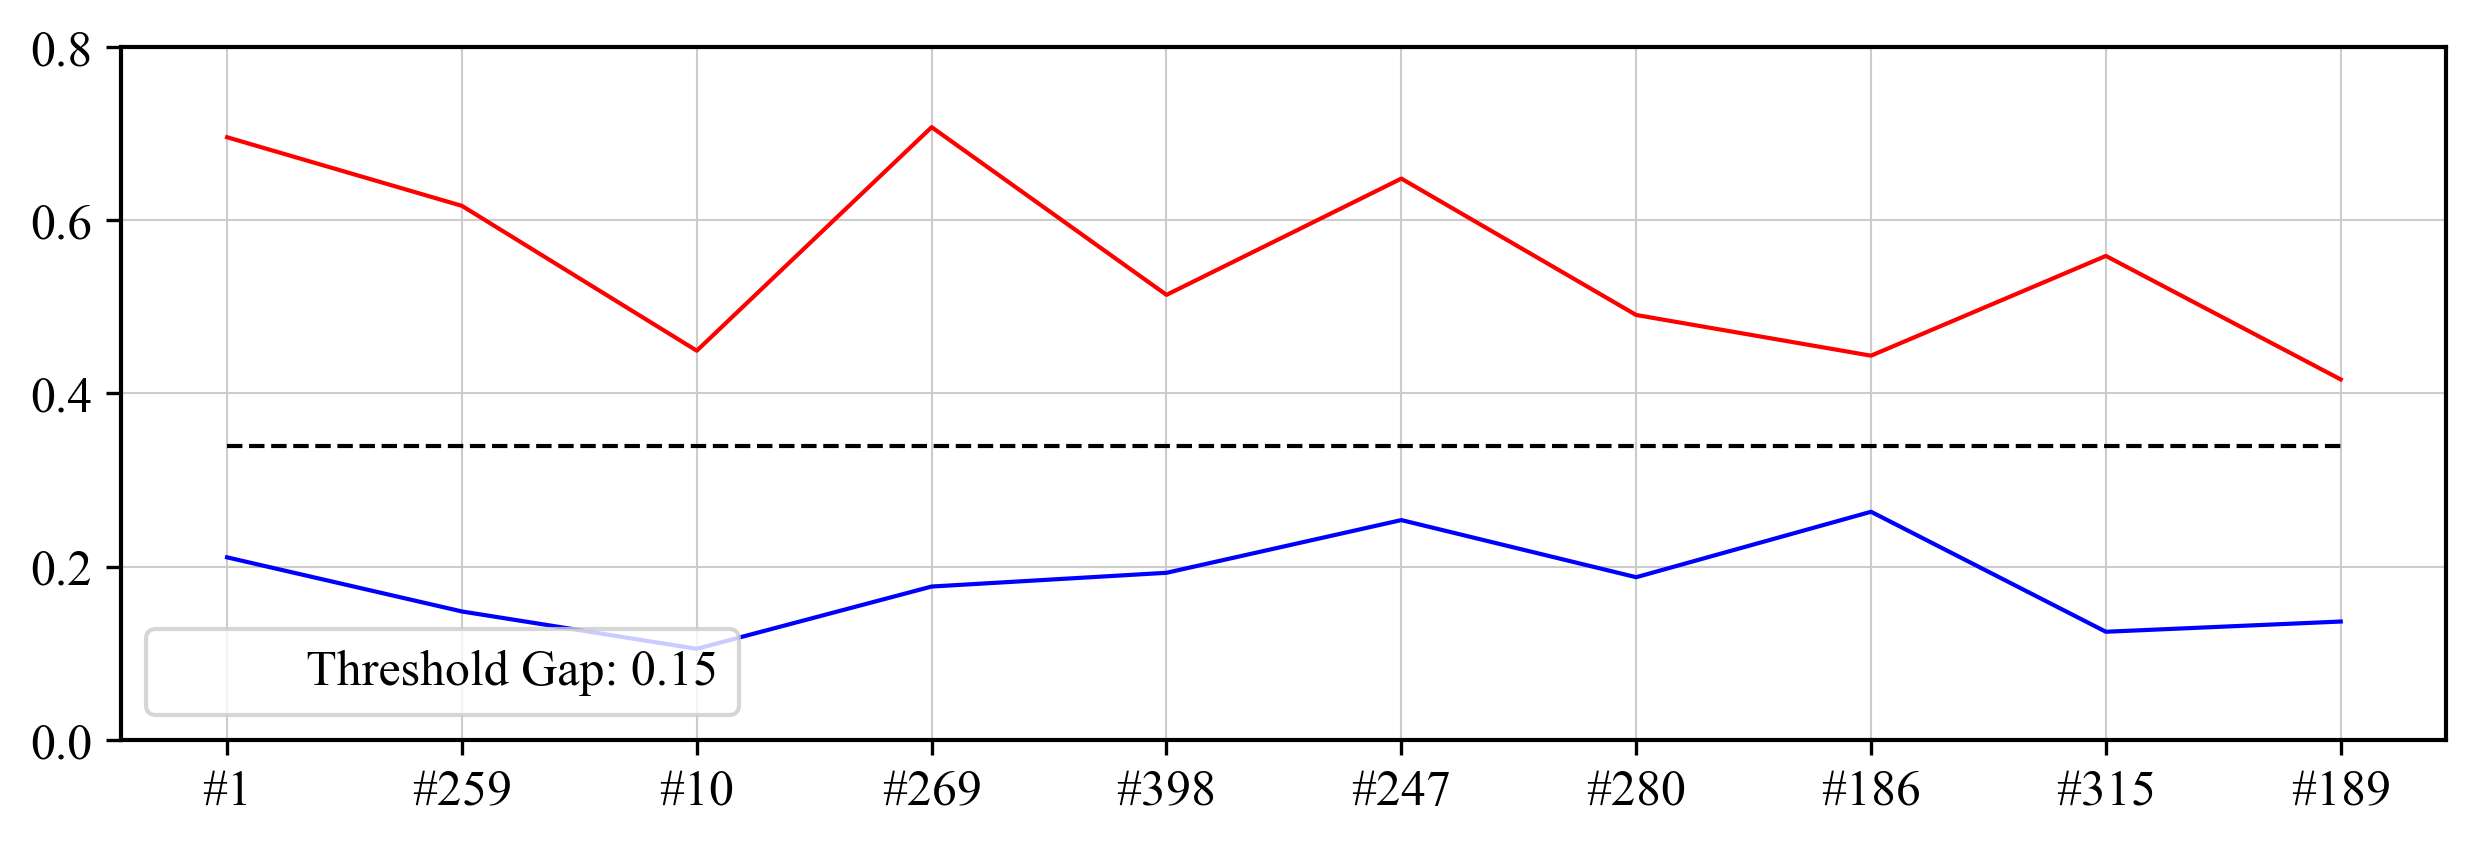

Generating eval finerprints for node1-1...
..Generating eval finerprints for node1-20...
..

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


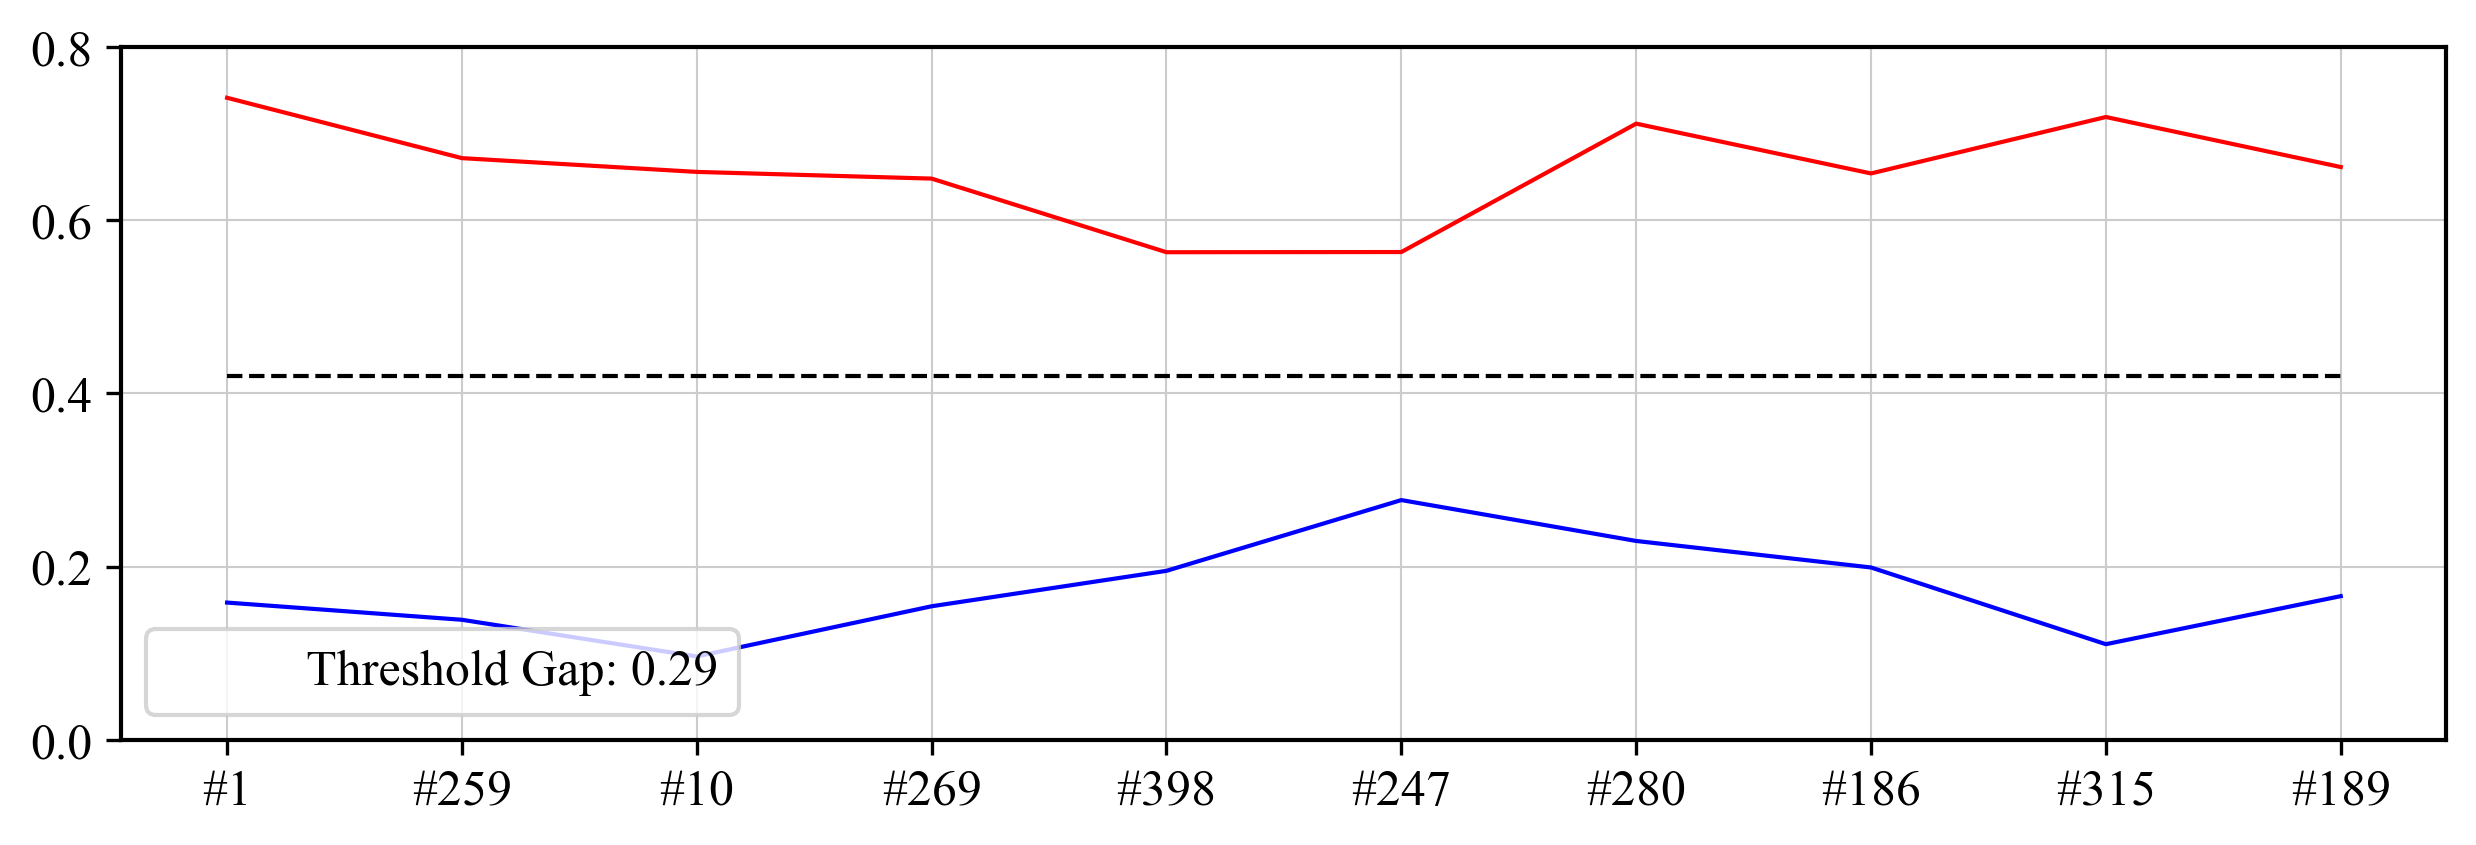

Generating eval finerprints for node1-1...
..Generating eval finerprints for node1-20...
..Generating eval finerprints for node19-19...
..

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


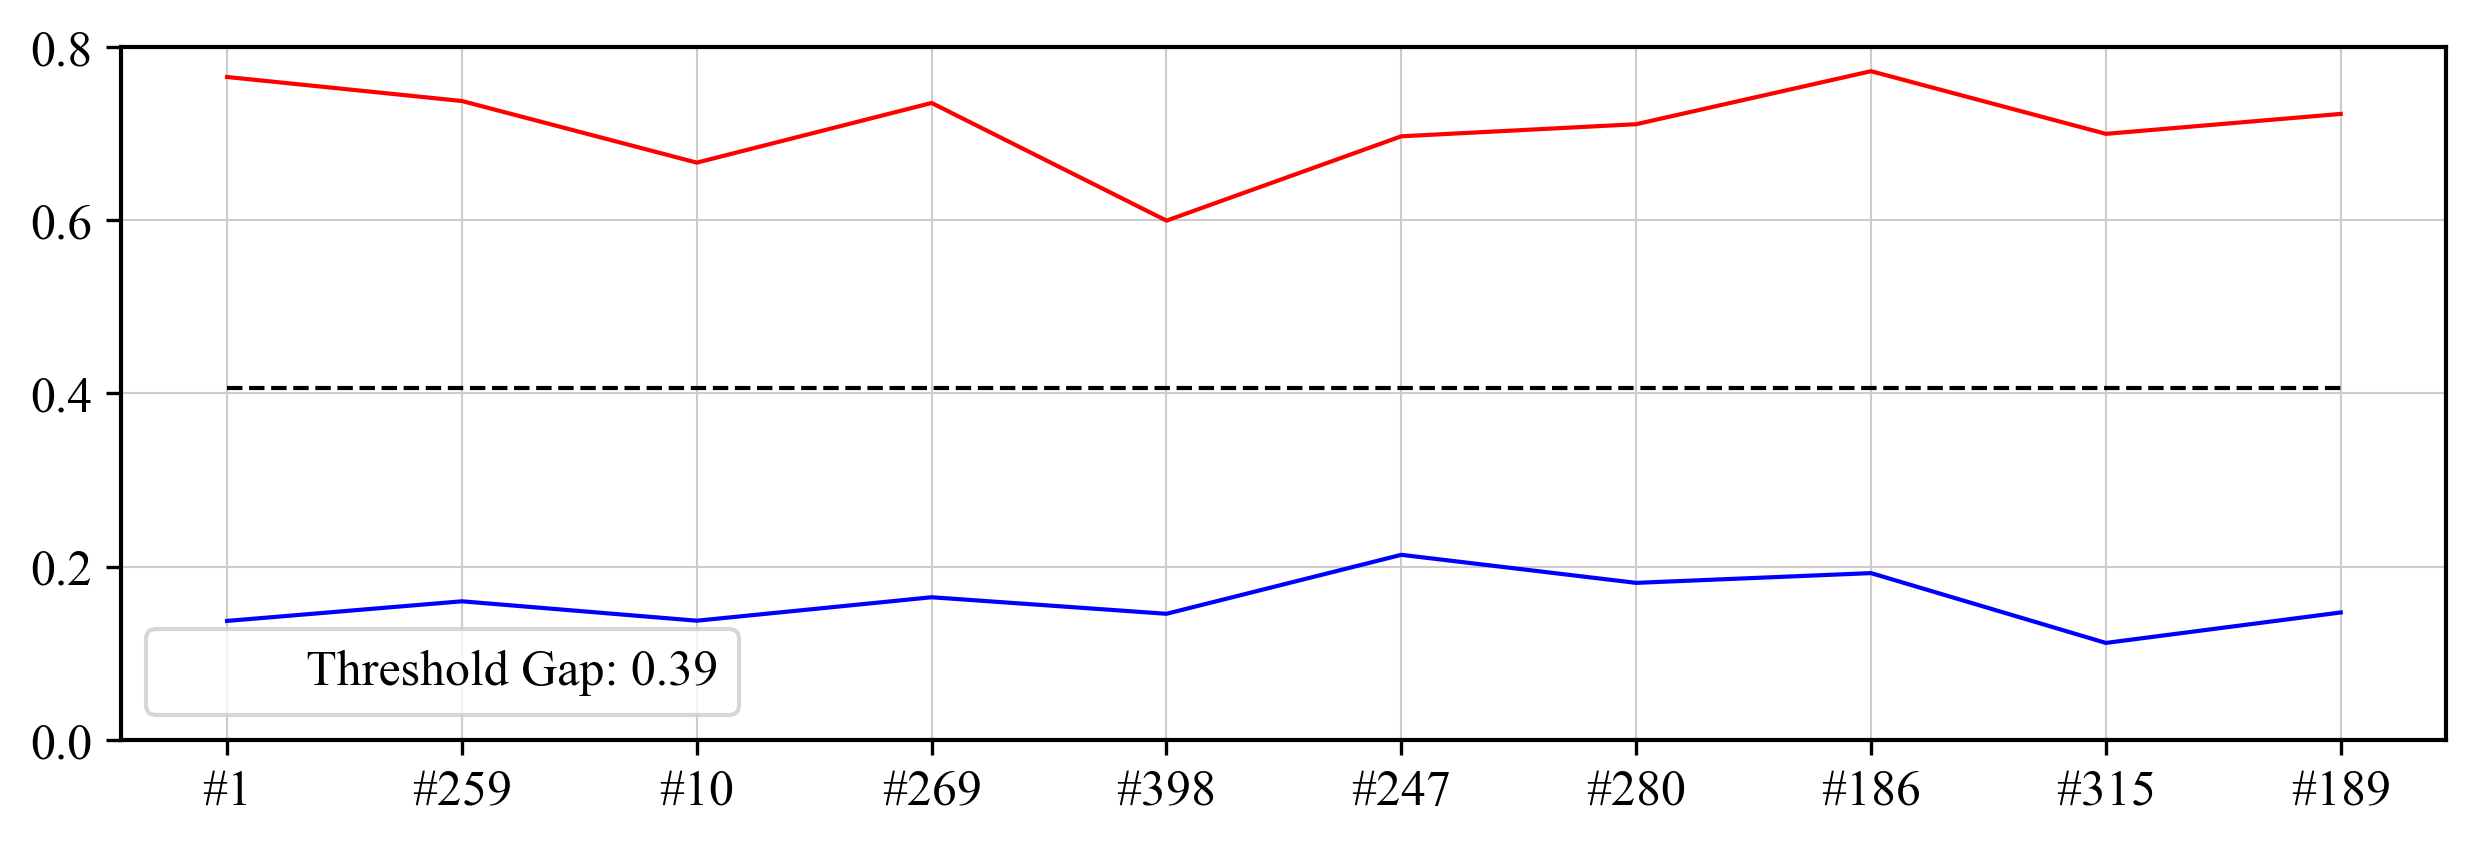

Generating eval finerprints for node1-1...
..Generating eval finerprints for node1-20...
..Generating eval finerprints for node19-19...
..

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


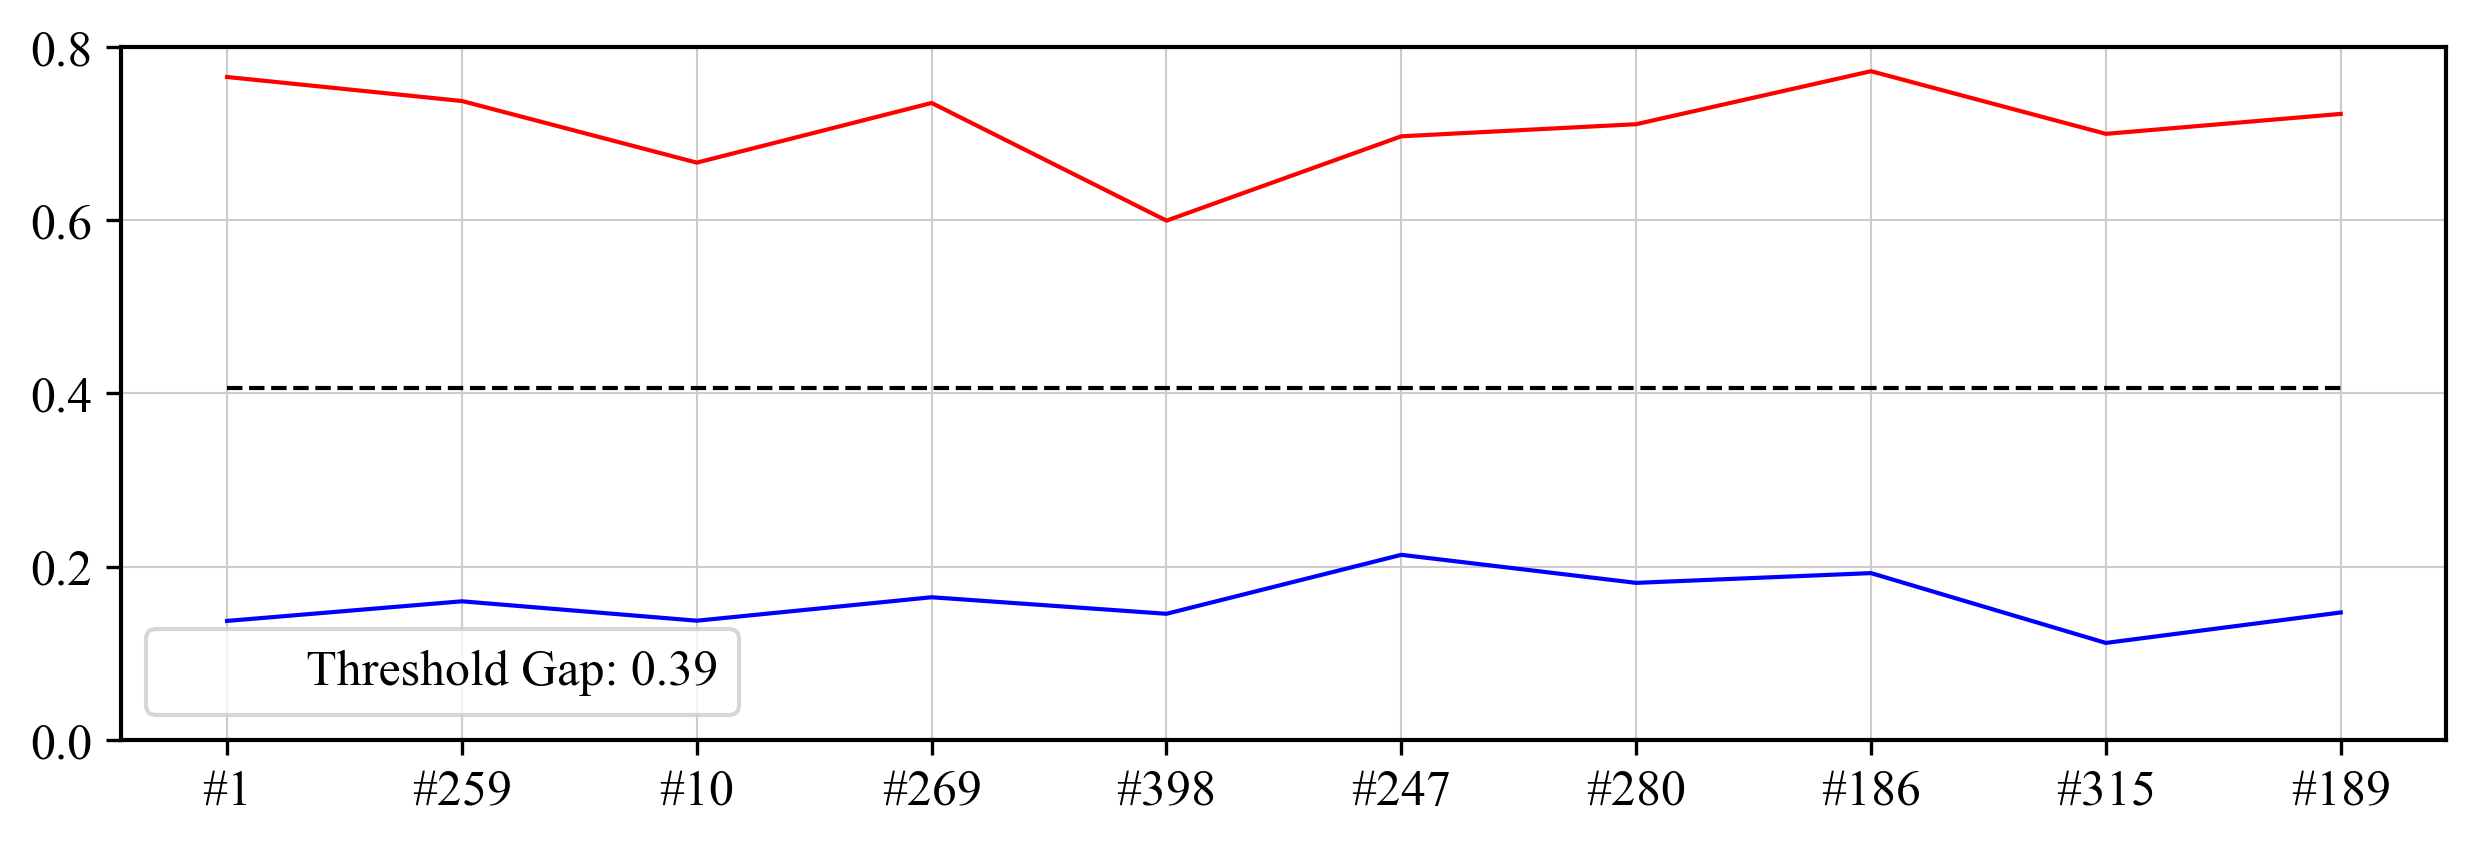

In [7]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    epochs = [
        'epoch_2024-07-20_01-15-26',
        'epoch_2024-07-20_01-25-24']
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    epochs = [
        'epoch_2024-08-08_19-19-27',
        'epoch_2024-08-08_19-59-37']
else:
    print(f'No configs for {DATASET_NAME}')

fp_distances_1 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[1:2], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_1.eps')

fp_distances_2 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[0:2], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_12.eps')

fp_distances_3 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[0:3], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_123.eps')

fp_distances_4 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[0:4], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_1234.eps')

In [14]:
diff_1 = min(fp_distances_1[:, 1]) - max(fp_distances_1[:, 0])
diff_2 = min(fp_distances_2[:, 1]) - max(fp_distances_2[:, 0])
diff_3 = min(fp_distances_3[:, 1]) - max(fp_distances_3[:, 0])
diff_4 = min(fp_distances_4[:, 1]) - max(fp_distances_4[:, 0])

print(f"Threshold gap w.r.t. RX 1, 2:       {round(100 * (diff_2 - diff_1) / diff_1, 2)}%")
print(f"Threshold gap w.r.t. RX 1, 2, 3:    {round(100 * (diff_3 - diff_1) / diff_1, 2)}%")
print(f"Threshold gap w.r.t. RX 1, 2, 3, 4: {round(100 * (diff_4 - diff_1) / diff_1, 2)}%")

print(f"Threshold gap w.r.t. RX 1           {round(diff_1, 2)}")
print(f"Threshold gap w.r.t. RX 1, 2:       {round(diff_2, 2)}")
print(f"Threshold gap w.r.t. RX 1, 2, 3:    {round(diff_3, 2)}")
print(f"Threshold gap w.r.t. RX 1, 2, 3, 4: {round(diff_4, 2)}")

Threshold gap w.r.t. RX 1, 2:       -345.83%
Threshold gap w.r.t. RX 1, 2, 3:    -362.52%
Threshold gap w.r.t. RX 1, 2, 3, 4: -362.52%
Threshold gap w.r.t. RX 1           -0.09
Threshold gap w.r.t. RX 1, 2:       0.22
Threshold gap w.r.t. RX 1, 2, 3:    0.23
Threshold gap w.r.t. RX 1, 2, 3, 4: 0.23


### Experient 5. Final results

In [7]:
enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_DEVICES
identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_DEVICES    

In [ ]:
epochs_idx_identify = np.arange(1, 15)
print(epochs_idx_identify) 

part1 = eval_api.evaluate_open_set_multirx(rx_ids = RX_NODES, 
    epoch_idx_enroll = 0, epochs_idx_identify = epochs_idx_identify,
    enroll_device_idx = enroll_device_idx[0:5],
    identify_device_idx = identify_device_idx,
    frame_count_enroll = 10, frame_count_identify = 10,
    enroll_threshold = 0, identify_threshold = 0.3,
    fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_open_set.eps'))

In [ ]:
epochs_idx_identify = np.arange(15, 30)
print(epochs_idx_identify) 

part1 = eval_api.evaluate_open_set_multirx(rx_ids = RX_NODES, 
    epoch_idx_enroll = 0, epochs_idx_identify = epochs_idx_identify,
    enroll_device_idx = enroll_device_idx[0:5],
    identify_device_idx = identify_device_idx,
    frame_count_enroll = 10, frame_count_identify = 10,
    enroll_threshold = 0, identify_threshold = 0.3,
    fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_open_set.eps'))

In [ ]:
epochs_idx_identify = np.arange(30, 45)
print(epochs_idx_identify) 

part1 = eval_api.evaluate_open_set_multirx(rx_ids = RX_NODES, 
    epoch_idx_enroll = 0, epochs_idx_identify = epochs_idx_identify,
    enroll_device_idx = enroll_device_idx[0:5],
    identify_device_idx = identify_device_idx,
    frame_count_enroll = 10, frame_count_identify = 10,
    enroll_threshold = 0, identify_threshold = 0.3,
    fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_open_set.eps'))

[45 46 47 48 49]
============= EPOCH 45 ============================
Enrolling device: (1, 1)
This is a new device. New ID: f806e7e3-7c1e-49b3-817d-7edfa45c7dc7
Enrolling device: (13, 19)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 01b068e0-5bac-42aa-a0df-e2bf061d636f
Enrolling device: (1, 10)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 04aab7b2-915d-4081-a064-b7f169899686
Enrolling device: (14, 9)
This is a new device. New ID: c1b1c499-a5ce-4f34-9a0e-0fa4b3b789dc
Enrolling device: (20, 18)
This is a new device. New ID: 8afbd8b0-f68f-4f81-b1bd-a37c20b53def
E45. Identifying a device: (1, 1)
This is a known device. ID: f806e7e3-7c1e-49b3-817d-7edfa45c7dc7
E45. Identifying a device: (13, 19)
This is a known device. ID: 01b068e0-5bac-42aa-a0df-e2bf061d636f
E45. Identifying a device: (1, 10)
This is a known device. ID: 04aab7b2-915d-4081-a064-b7f169899686
E45. Identifying a device: (14, 9)
This is a known device. ID: c1b1c499-a5ce-4f34-9a0e-0fa4b3b789dc
E45. Identifying a device: (20, 18)
This is a known device. ID: 8afbd8b0-f68f-4f81-b1bd-a37c20b53def
E45. Identifying a device: (13, 7)
This is a new device. New ID: 39cd2f13-04a7-4861-8e06-98a59d976bab
E45. Identifying a device: (14, 20)
This is a new device. New ID: 11e5adc2-7700-4edb-bab6-580efe1d9769
E45. Identifying a device: (10, 6)
This 

...

This is a new device. New ID: da260059-561a-4bfa-a710-05eb2c6f2c24
Enrolling device: (1, 10)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 5b9fa5ff-d2f6-4033-9e27-5fdc854518ce
Enrolling device: (14, 9)
This is a new device. New ID: caa746fa-e067-4e77-98d2-7ac44e2324f0
Enrolling device: (20, 18)
This is a new device. New ID: 47b5f962-d0c0-45a8-b456-b7cc19853778
E49. Identifying a device: (1, 1)
This is a known device. ID: 5c6be294-7bb1-44bb-9c9b-f80431d9fcd7
E49. Identifying a device: (13, 19)
This is a known device. ID: da260059-561a-4bfa-a710-05eb2c6f2c24
E49. Identifying a device: (1, 10)
This is a known device. ID: 5b9fa5ff-d2f6-4033-9e27-5fdc854518ce
E49. Identifying a device: (14, 9)
This is a known device. ID: caa746fa-e067-4e77-98d2-7ac44e2324f0
E49. Identifying a device: (20, 18)
This is a known device. ID: 47b5f962-d0c0-45a8-b456-b7cc19853778
E49. Identifying a device: (13, 7)
This is a new device. New ID: 7ffcdc9d-d733-4dc8-a018-ce7b4bdca9e7
E49. Identifying a device: (14, 20)
This is a new device. New ID: f276586d-67aa-4d18-bd59-715036028c30
E49. Identifying a device: (10, 6)
This 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


This is a new device. New ID: 7acf4129-6a3c-423c-a2b1-a24361dbc3bd
[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
[0.0571671209708407, 0.10282854184234134, 0.09692233427154517, 0.12087238873171917, 0.06411793292991665, 0.7211699167672977, 0.623828342301399, 0.5951062807083476, 0.6937752925159449, 0.6399971600935698, 0.06624569159708653, 0.08711266579033174, 0.09141546554955116, 0.1032268551829212, 0.05851833841012488, 0.7027676227021685, 0.6275539739569469, 0.6035379746784524, 0.6914651524682672, 0.616137185829624, 0.08831258470870369, 0.14019471156043306, 0.116514770394379, 0.13487715925713956, 0.13379986403468466, 0.688711428859868, 0.6425581763234866, 0.6193805874520136, 0.7187104331632174, 0.6394166887894561, 0.05872044832704084, 0.12785898135855786, 0.108519868194509, 0.15805239895616408, 0.09171889072089918, 0.7222604303626894, 0.6269640014962458, 0.6063908207990573, 0.70294497

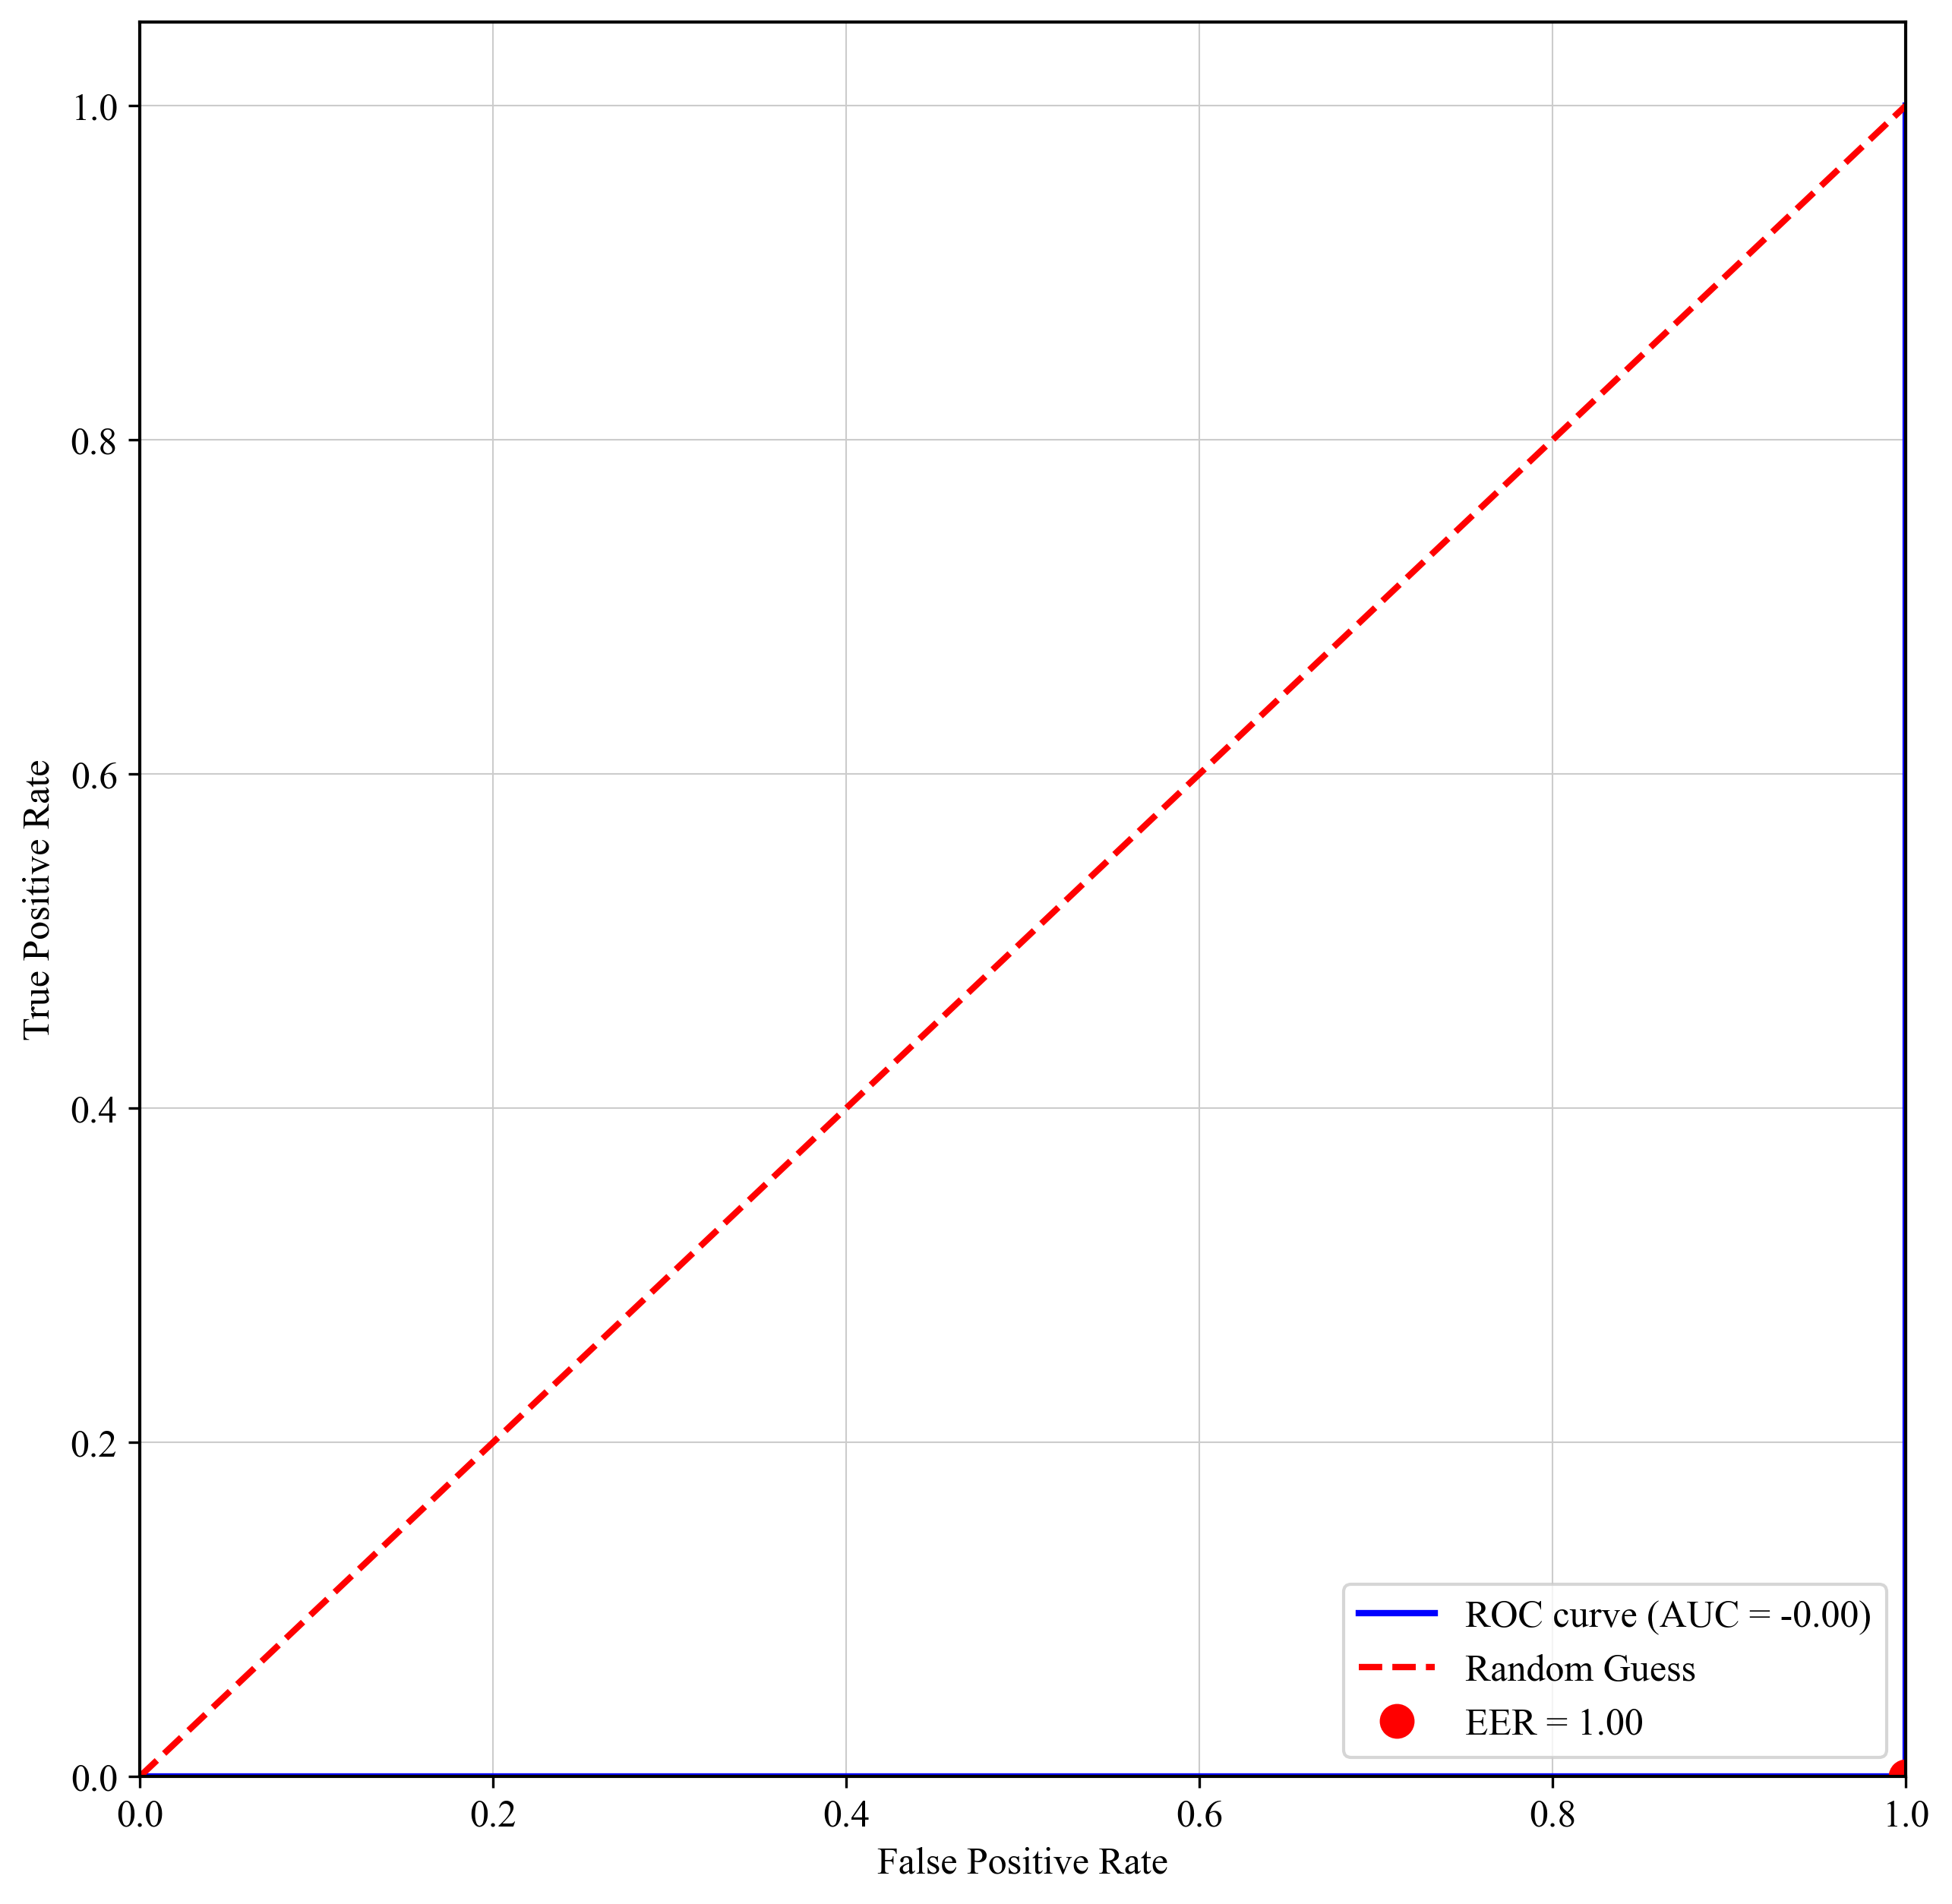

In [9]:
epochs_idx_identify = np.arange(45, 50)
print(epochs_idx_identify) 

part1 = eval_api.evaluate_open_set_multirx(rx_ids = RX_NODES, 
    epoch_idx_enroll = 0, epochs_idx_identify = epochs_idx_identify,
    enroll_device_idx = enroll_device_idx[0:5],
    identify_device_idx = identify_device_idx,
    frame_count_enroll = 10, frame_count_identify = 10,
    enroll_threshold = 0, identify_threshold = 0.3,
    fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_open_set.eps'))

Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: d13ed5f0-4996-4ca0-937e-7ab17e680930
Enrolling device: (14, 9)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: b328e205-3470-44c4-93c0-e45e87156694
Enrolling device: (14, 20)
This is a new device. New ID: f78a327a-af30-456a-b68f-e5ce53880a01
Enrolling device: (15, 20)
This is a new device. New ID: 9247227f-8426-4821-af36-f1d4dd6413c0
E167. Identifying a device: (2, 19)
This is a known device. ID: 361c1140-656a-4f27-846b-4e9cdaefdb9f
E167. Identifying a device: (12, 19)
This is a known device. ID: d13ed5f0-4996-4ca0-937e-7ab17e680930
E167. Identifying a device: (14, 9)
This is a known device. ID: b328e205-3470-44c4-93c0-e45e87156694
E167. Identifying a device: (14, 20)
This is a known device. ID: f78a327a-af30-456a-b68f-e5ce53880a01
E167. Identifying a device: (15, 20)
This is a known device. ID: 9247227f-8426-4821-af36-f1d4dd6413c0
E167. Identifying a device: (16, 15)
This is a new device. New ID: 938689df-2b2f-4a42-9d96-419a1059c0fc
E167. Identifying a device: (17, 10)
This is a new device. New ID: d05bc299-ecd8-4f64-b15c-ed414980f3f8
E167. Identifying a device: (

...

Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 365d21fb-e890-4a1b-a13b-50f77fb7ca6d
Enrolling device: (14, 9)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 55e9953f-5b60-4104-9593-f80f10570a1d
Enrolling device: (14, 20)
This is a new device. New ID: b2d9b58c-9411-4f92-91a4-36ecb2b3f162
Enrolling device: (15, 20)
This is a new device. New ID: 1c16ef64-ab6d-48e2-9816-b993756fa5d5
E169. Identifying a device: (2, 19)
This is a known device. ID: 3ef48bab-c6b2-40b4-8b3c-2f0fbba84ddc
E169. Identifying a device: (12, 19)
This is a known device. ID: 365d21fb-e890-4a1b-a13b-50f77fb7ca6d
E169. Identifying a device: (14, 9)
This is a known device. ID: 55e9953f-5b60-4104-9593-f80f10570a1d
E169. Identifying a device: (14, 20)
This is a known device. ID: b2d9b58c-9411-4f92-91a4-36ecb2b3f162
E169. Identifying a device: (15, 20)
This is a known device. ID: 1c16ef64-ab6d-48e2-9816-b993756fa5d5
E169. Identifying a device: (16, 15)
This is a new device. New ID: 16e1254a-0157-4818-8931-3e4158d4ac2c
E169. Identifying a device: (17, 10)
This is a new device. New ID: b891cb63-beb9-4c7b-be94-06f5a7b0ca5c
E169. Identifying a device: (

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


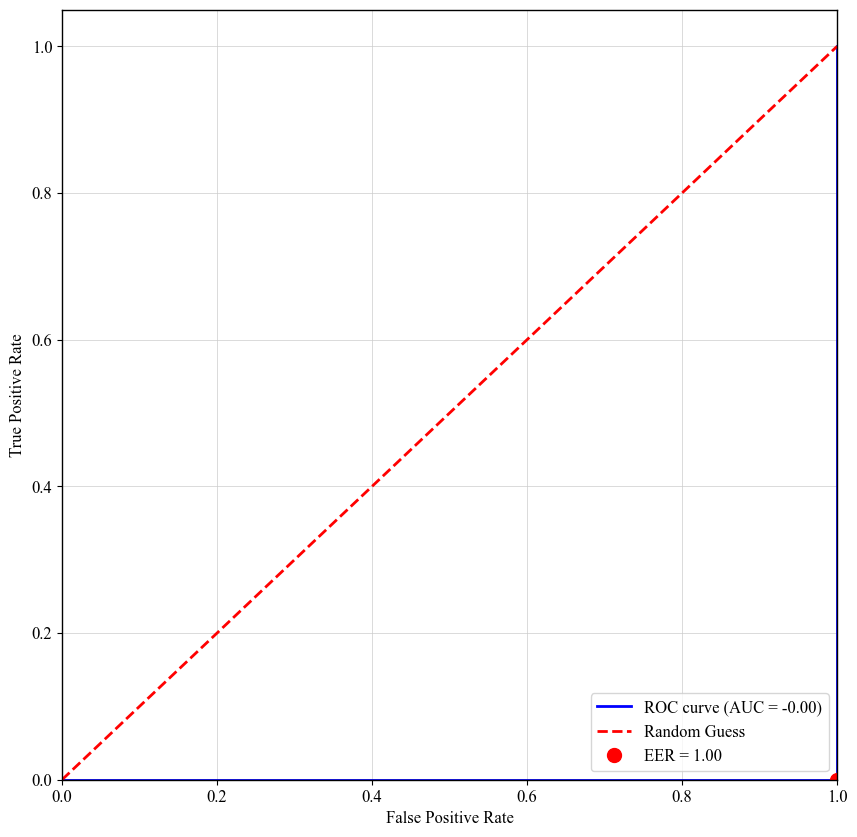

In [6]:
enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
epochs_idx_identify = np.arange(150, 170)
print(epochs_idx_identify)

part5 = eval_api.evaluate_open_set_multirx(rx_ids = RX_NODES, 
    epoch_idx_enroll = 0, epochs_idx_identify = epochs_idx_identify,
    enroll_device_idx = enroll_device_idx[0:5],
    identify_device_idx = identify_device_idx,
    frame_count_enroll = 10, frame_count_identify = 10,
    enroll_threshold = 0, identify_threshold = 0.3,
    fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_open_set.eps'))

In [ ]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
    epochs_idx_identify = np.arange(1, 170)
    # epochs_idx_identify = np.arange(1, 25)
    # epochs_idx_identify = [1]
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_DEVICES
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_DEVICES
    epochs_idx_identify = np.arange(1, 50)
    # epochs_idx_identify = np.arange(1, 5)
else:
    print(f'No configs for {DATASET_NAME}')

# eval_api.evaluate_closed_set_multirx(rx_ids = RX_NODES, 
#     epoch_idx_enroll = 0, epochs_idx_identify = epochs_idx_identify,
#     enroll_device_idx = enroll_device_idx,
#     identify_device_idx =identify_device_idx,
#     frame_count_enroll = 10, frame_count_identify = 10,
#     enroll_threshold = 0, identify_threshold = 0.55,
#     fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_closed_set.eps'))

eval_api.evaluate_open_set_multirx(rx_ids = RX_NODES, 
    epoch_idx_enroll = 0, epochs_idx_identify = epochs_idx_identify,
    enroll_device_idx = enroll_device_idx[0:5],
    identify_device_idx = identify_device_idx,
    frame_count_enroll = 10, frame_count_identify = 10,
    enroll_threshold = 0, identify_threshold = 0.3,
    fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_open_set.eps'))

75
75


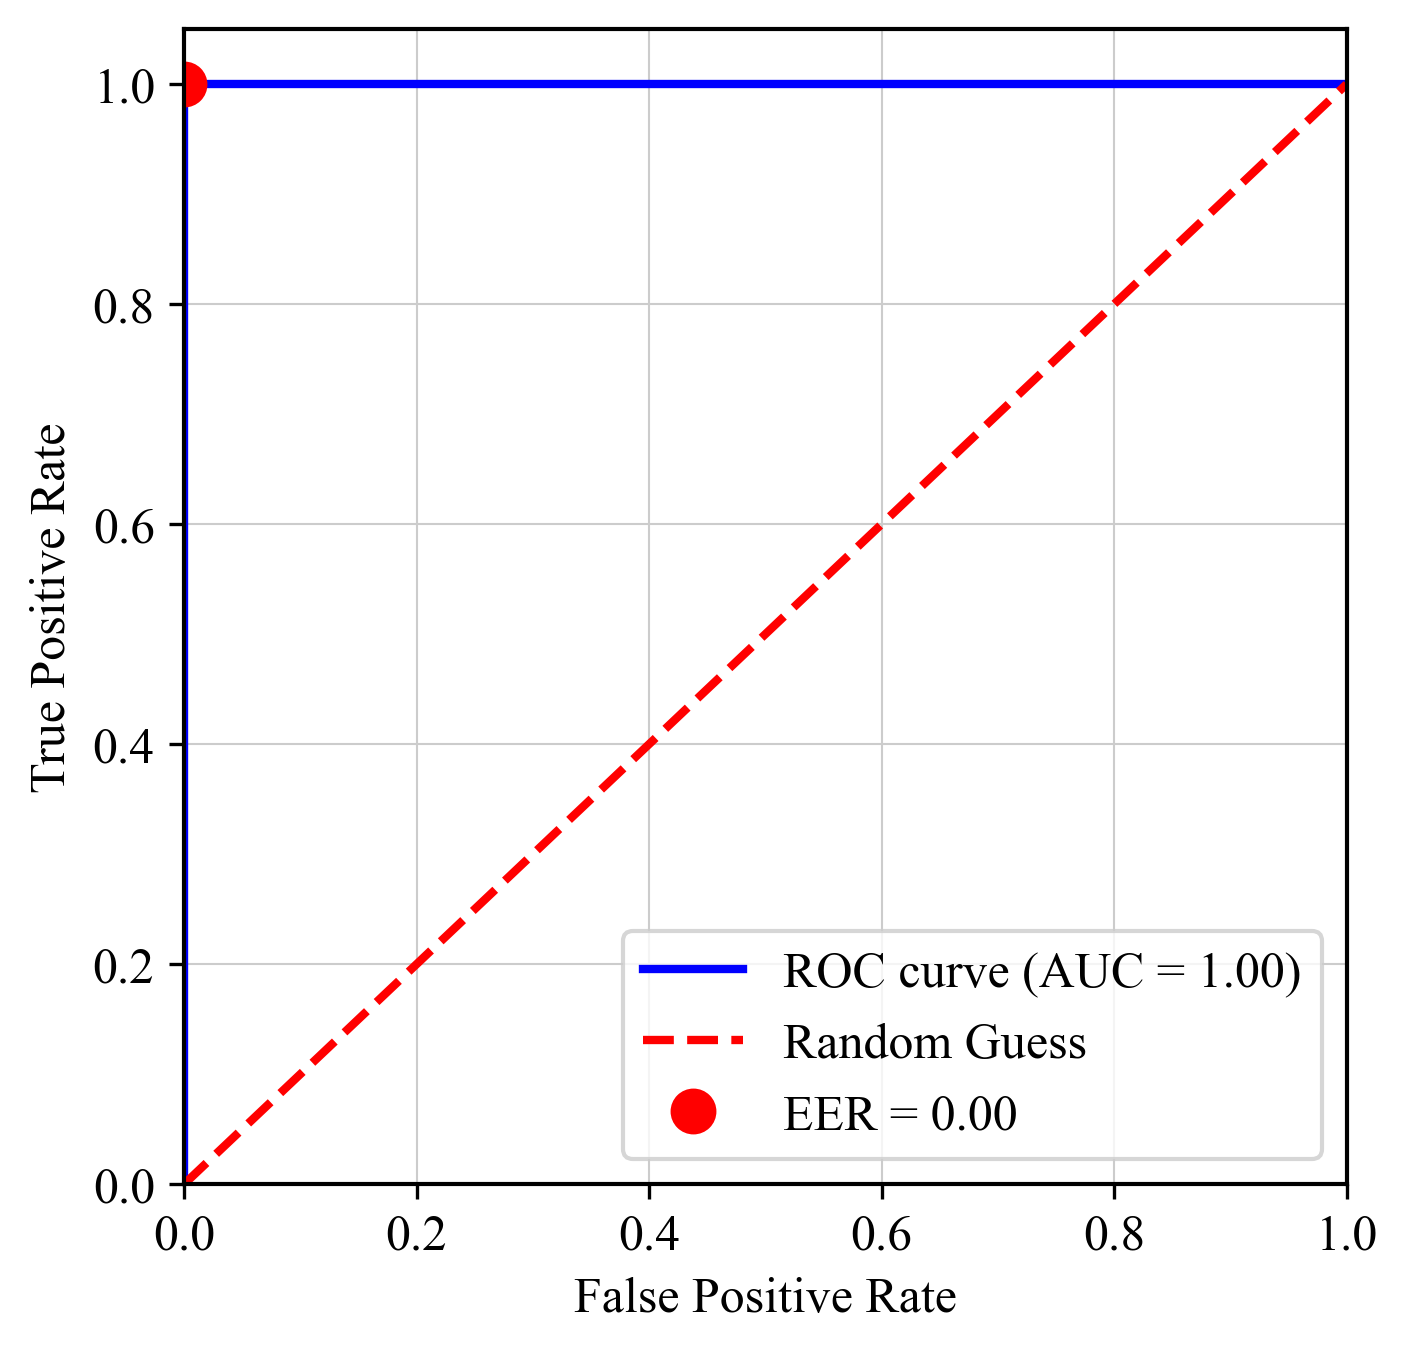

In [7]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

labels_real = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
labels_pred = [0.09873469575717764, 0.1564113386674853, 0.1640191678041514, 0.10786143792527624, 0.11756625702297534, 0.4956640343670737, 0.5850014434998214, 0.508290688355698, 0.5645850052751582, 0.576760874605309, 0.4573264282613126, 0.5164090125577813, 0.5865572757504743, 0.4328916736712, 0.4987378348928202, 0.4913734342592302, 0.5332694055618719, 0.4689778141282423, 0.43099259907788684, 0.11868054488846043, 0.1113118885039463, 0.1091841059203842, 0.11570322919888298, 0.13897113986393553, 0.4330518254758478, 0.6436290519315722, 0.5598078684123358, 0.6030627553567164, 0.5535731612702511, 0.48985958716803096, 0.4902441547529275, 0.5704997090459304, 0.4676898184334082, 0.5057978600070052, 0.5073630393084985, 0.5140487632326743, 0.47401444907289675, 0.45946474450007413, 0.13768745159844042, 0.18619008481044882, 0.11213764270194666, 0.16695220023864998, 0.4580079834312734, 0.5999811754154732, 0.5173015595650045, 0.5893408994974748, 0.5611331723073952, 0.4646403787830568, 0.5153897602307899, 0.5811015325566905, 0.4822289633725438, 0.5165533987764803, 0.5067648801742145, 0.5258701292951385, 0.4452318783245399, 0.4522954459752188, 0.12726759162516915, 0.1148449652939242, 0.14669736790282162, 0.22626683439180784, 0.1328670778547473, 0.4219602277070244, 0.6894044412310673, 0.5375969121786287, 0.5736177772692121, 0.5578604042205867, 0.46053838141413017, 0.5501897572652337, 0.5711637076745016, 0.42688274432887113, 0.5140644413575823, 0.4969564054246735, 0.5228033825673856, 0.4602023347917365, 0.4457406287284799]

print(len(labels_real))
print(len(labels_pred))

# Compute receiver operating characteristic (ROC).
fpr, tpr, _ = roc_curve(labels_real, labels_pred)

# # Invert false positive and true positive ratios to convert from distances to probabilities
# fpr = 1 - fpr  
# tpr = 1 - tpr

# Compute EER
fnr = 1-tpr
abs_diffs = np.abs(fpr - fnr)
min_index = np.argmin(abs_diffs)
eer = np.mean((fpr[min_index], fnr[min_index]))

# Compute AUC
roc_auc = auc(fpr, tpr)

utils.apply_ieee_style()
plt.figure(figsize=(5, 5))
eer_point = min(zip(fpr, tpr), key=lambda x: abs(x[0] - (1-x[1])))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.plot(eer_point[0], eer_point[1], 'ro', markersize=10, label=f'EER = {eer:.2f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve for Weighted KNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 6. That's all, folks!

Thank you for exploring our project! If you found this useful, please consider citing our paper. This would mean the world to our team.

![](https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXhkMmpnZTl0ZmYybWd6NzExMWdxNmY1ZmE4Y2h0d3Zsem96ZG9yMSZlcD12MV9naWZzX3NlYXJjaCZjdD1n/lTpme2Po0hkqI/giphy.gif)

```bibtex
@article{mazokha2024rffi,
  title={RFFI for Mobility Intelligence and MAC Address Derandomization},
  author={Mazokha, Stepan and Bao, Fanchen and Sklivanitis, George and Hallstrom, Jason O},
  journal={TBD},
  year={2024},
  publisher={TBD}
}